### 1. Top Performing Lower-Order Finishers in Run Chases
Problem Statement: Identify the top 10 players who act as "finishers" by having the highest average strike rate in the 2nd innings, specifically when batting for wickets 7 to 10, with a minimum of 5 such partnership appearances.

Explanation: This analysis focuses on pressure situations (2nd innings) and lower-order stability. It uses player_1_runs, player_1_balls, and innings to calculate strike rates for late-game players.

Visuals: Bar Chart & Table.

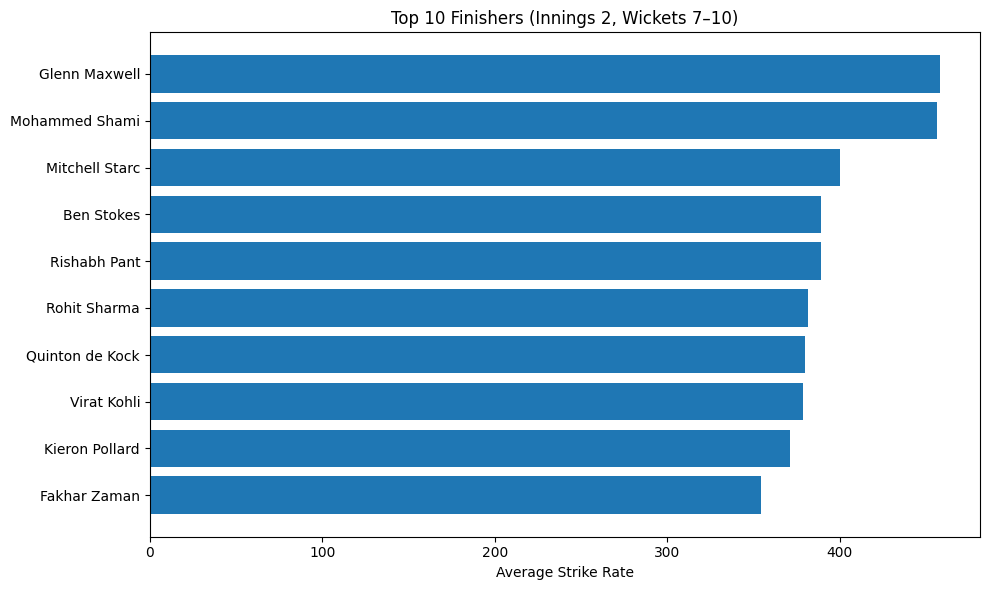


Top Finishers Table:

  player_1_name     avg_sr  matches
  Glenn Maxwell 458.455397      278
 Mohammed Shami 456.315407      282
 Mitchell Starc 400.138849      266
     Ben Stokes 388.993819      276
   Rishabh Pant 388.934996      266
   Rohit Sharma 381.410229      257
Quinton de Kock 380.122282      265
    Virat Kohli 378.950268      272
 Kieron Pollard 371.308693      258
   Fakhar Zaman 354.269071      290


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Avoid division by zero
df['player_1_balls'] = df['player_1_balls'].replace(0, np.nan)

# Strike rate calculation
df['sr_1'] = (df['player_1_runs'] / df['player_1_balls']) * 100

# Filter finishers (innings 2, wickets 7–10)
finishers = df[(df['innings'] == 2) & (df['for_wicket'] >= 7)]

# Grouping
p1_finish = finishers.groupby('player_1_name').agg(
    avg_sr=('sr_1', 'mean'),
    matches=('match_id', 'count')
).reset_index()

# Filter minimum matches
p1_finish = p1_finish[p1_finish['matches'] >= 5]

# Sort and take top 10
p1_finish = p1_finish.sort_values(by='avg_sr', ascending=False).head(10)

# -------- Visual 1: Bar Chart --------
plt.figure(figsize=(10, 6))
plt.barh(p1_finish['player_1_name'], p1_finish['avg_sr'])
plt.xlabel('Average Strike Rate')
plt.title('Top 10 Finishers (Innings 2, Wickets 7–10)')
plt.gca().invert_yaxis()  # Highest on top
plt.tight_layout()
plt.savefig('finishers_bar.png')
plt.show()

# -------- Visual 2: Table --------
print("\nTop Finishers Table:\n")
print(p1_finish[['player_1_name', 'avg_sr', 'matches']].to_string(index=False))

### 2. High-Efficiency Middle Order Partnerships
Problem Statement: Find the top partnership pairs (Player 1 and Player 2) that maintained a combined strike rate of over 150 in the 1st innings while batting for the 3rd, 4th, or 5th wicket.

Explanation: This looks at the efficiency of the middle order in setting a target. It filters by innings, for_wicket, and calculates a new efficiency metric from partnership_runs and partnership_balls.

Visuals: Bar Chart & Text.

Total aggressive partnerships found: 2412


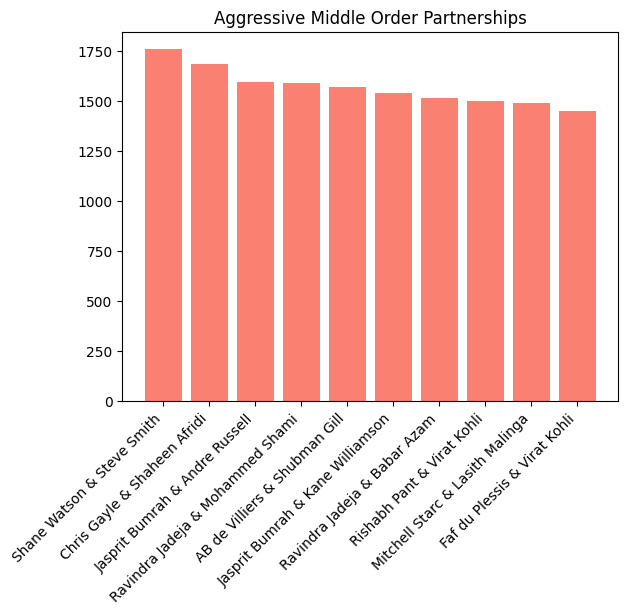

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
df['p_sr'] = (df['partnership_runs'] / df['partnership_balls']) * 100
mid_order = df[(df['innings'] == 1) & (df['for_wicket'].isin([3, 4, 5])) & (df['p_sr'] > 150)]
mid_agg = mid_order.groupby(['player_1_name', 'player_2_name']).agg({'partnership_runs': 'sum'}).reset_index().sort_values(by='partnership_runs', ascending=False).head(10)

# Visual 1: Bar Chart
plt.bar(mid_agg['player_1_name'] + " & " + mid_agg['player_2_name'], mid_agg['partnership_runs'], color='salmon')
plt.title('Aggressive Middle Order Partnerships')
plt.xticks(rotation=45, ha='right')
plt.savefig('middle_order_bar.png')

# Visual 2: Text
print(f"Total aggressive partnerships found: {len(mid_order)}")

### 3. Clean Hitting: High Runs with Minimal Extras
Problem Statement: Analyze the top-order partnerships (wickets 1-3) that scored over 150 runs where the "Extra Runs" contributed less than 5% of the total partnership score.

Explanation: This identifies technically sound partnerships with high discipline from the bowling side or high control from batsmen. It affects partnership_runs, extra_runs_in_partnership, and for_wicket.

Visuals: Pie Chart & Table.

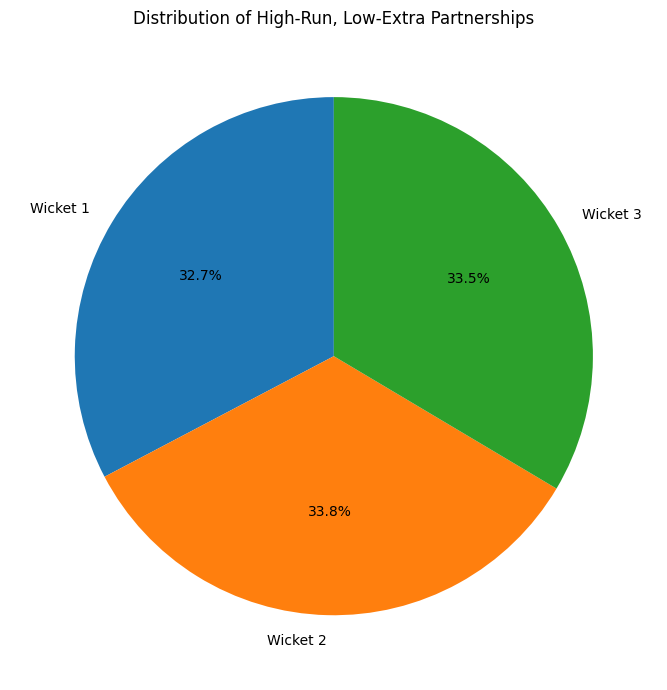


Summary Table:

 for_wicket  count
          1   1061
          2   1095
          3   1088

Sample High-Quality Partnerships:

    match_id  for_wicket  partnership_runs  extra_runs_in_partnership
MATCH_169219           1               308                         10
MATCH_852092           1               307                          9
MATCH_873022           1               307                         14
MATCH_858351           2               306                         15
MATCH_297229           3               305                         15
MATCH_837497           1               305                         15
MATCH_746853           3               305                         15
MATCH_569257           2               304                         12
MATCH_776466           3               304                          6
MATCH_806210           2               304                          9


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Clean data (avoid issues)
df['extra_runs_in_partnership'] = df['extra_runs_in_partnership'].fillna(0)
df['partnership_runs'] = df['partnership_runs'].replace(0, np.nan)

# High Contribution, Low Extras filter
hc_le = df[
    (df['partnership_runs'] > 150) &
    (df['extra_runs_in_partnership'] < (0.05 * df['partnership_runs'])) &
    (df['for_wicket'] <= 3)
]

# Grouping
summary = hc_le.groupby('for_wicket').size()

# -------- Visual 1: Pie Chart --------
plt.figure(figsize=(7, 7))
labels = [f"Wicket {i}" for i in summary.index]

plt.pie(summary, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of High-Run, Low-Extra Partnerships')
plt.tight_layout()
plt.savefig('hc_le_pie.png')
plt.show()

# -------- Visual 2: Better Table --------
print("\nSummary Table:\n")
print(summary.reset_index(name='count').to_string(index=False))

print("\nSample High-Quality Partnerships:\n")
print(hc_le[['match_id', 'for_wicket', 'partnership_runs', 'extra_runs_in_partnership']]
      .sort_values(by='partnership_runs', ascending=False)
      .head(10)
      .to_string(index=False))

### 4. One-Man Show: Dominant Player Contributions
Problem Statement: Identify instances where Player 1 contributed more than 70% of the total runs in a partnership that lasted at least 100 runs.

Explanation: This highlights "lone wolf" performances where one player dominates the scoring. It involves calculating the ratio between player_1_runs and partnership_runs.

Visuals: Bar Chart & Infographic (Text Summary).

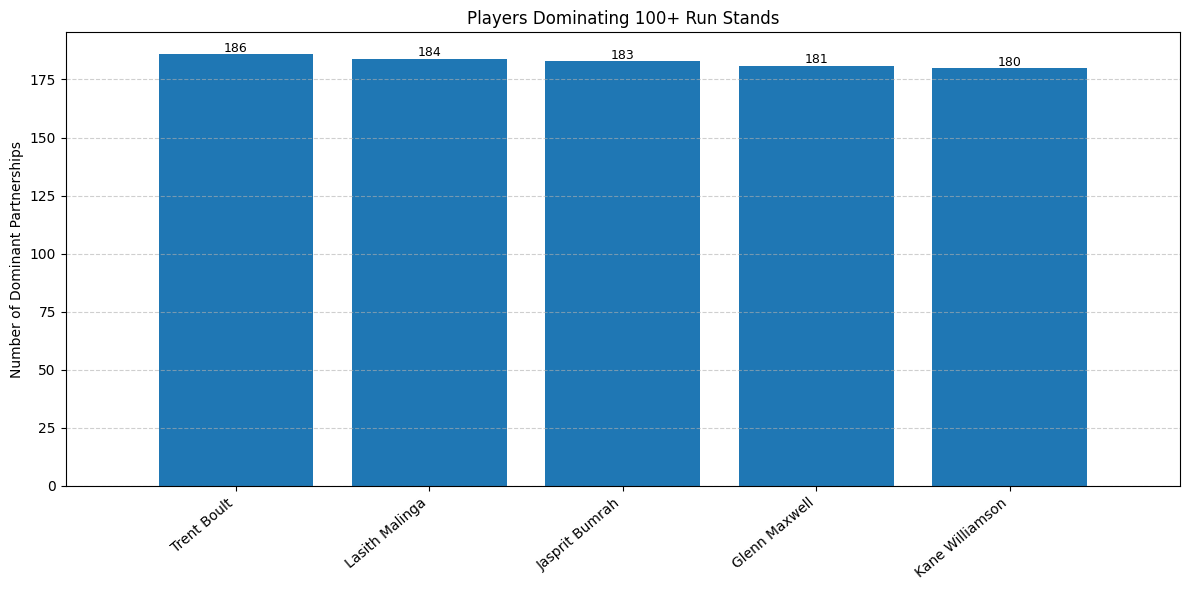

Insight: Trent Boult has dominated the most partnerships in the dataset.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Load data
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Clean columns
df.columns = df.columns.str.strip()

# Conditions
dominant = df[
    (df['partnership_runs'] >= 100) & 
    (df['player_1_runs'] / df['partnership_runs'] > 0.7)
]

dom_counts = dominant['player_1_name'].value_counts().head(5)

# ---------------- VISUAL ----------------
plt.figure(figsize=(12,6))

bars = plt.bar(dom_counts.index, dom_counts.values)

plt.title('Players Dominating 100+ Run Stands')
plt.ylabel('Number of Dominant Partnerships')

# 🔥 SPACING FIXES
plt.xticks(rotation=40, ha='right', fontsize=10)   # rotate labels
plt.margins(x=0.1)                                 # add horizontal spacing
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on top (professional touch)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             int(height), ha='center', fontsize=9)

plt.tight_layout()  # auto spacing

plt.savefig('dominant_p1_bar.png')
plt.show()

# ---------------- TEXT ----------------
print(f"Insight: {dom_counts.index[0]} has dominated the most partnerships in the dataset.")

### 5. Identifying Ball-Consuming Opening Pairs

Problem Statement: Compare the opening pairs (1st wicket) in the 1st innings to find which pairs faced the most balls while maintaining a partnership average of less than 100 runs.

Explanation: This helps identify "slow" starts that might put pressure on the later batsmen. It uses partnership_balls, partnership_runs, and for_wicket.

Visuals: Table & Bar Chart.


Top Inefficient Opening Pairs:

                          pair  total_balls  total_runs  run_rate
     Ben Stokes & Shubman Gill          556         272  2.935252
 Virat Kohli & Kane Williamson          403         183  2.724566
Andre Russell & Faf du Plessis          394         217  3.304569
 Fakhar Zaman & Jasprit Bumrah          379         251  3.973615
     Kieron Pollard & MS Dhoni          365         187  3.073973
     Joe Root & Jasprit Bumrah          355         124  2.095775
  Chris Gayle & Lasith Malinga          333         115  2.072072
           MS Dhoni & Joe Root          331         150  2.719033
Kane Williamson & Shane Watson          331         210  3.806647
  Hardik Pandya & Rohit Sharma          331         146  2.646526


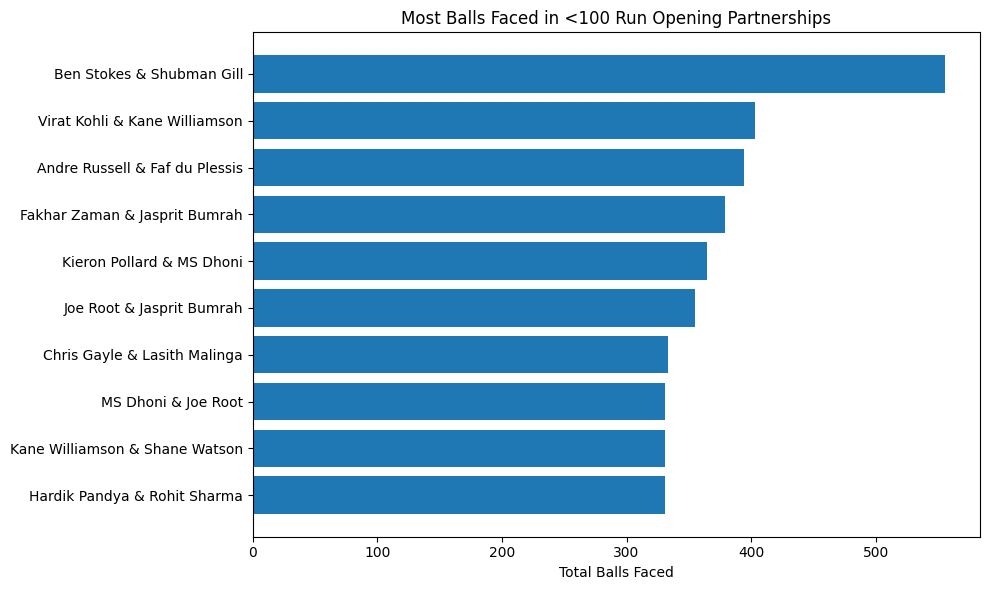

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Clean data
df['partnership_balls'] = df['partnership_balls'].replace(0, np.nan)

# Filter: Opening partnerships (<100 runs, innings 1)
openers = df[
    (df['innings'] == 1) &
    (df['for_wicket'] == 1) &
    (df['partnership_runs'] < 100)
]

# Create pair label
openers['pair'] = openers['player_1_name'] + " & " + openers['player_2_name']

# Aggregate
openers_agg = openers.groupby('pair').agg(
    total_balls=('partnership_balls', 'sum'),
    total_runs=('partnership_runs', 'sum')
).reset_index()

# Add run rate (important insight)
openers_agg['run_rate'] = (openers_agg['total_runs'] / openers_agg['total_balls']) * 6

# Sort
openers_agg = openers_agg.sort_values(by='total_balls', ascending=False).head(10)

# -------- Visual 1: Table --------
print("\nTop Inefficient Opening Pairs:\n")
print(openers_agg.to_string(index=False))

# -------- Visual 2: Horizontal Bar Chart --------
plt.figure(figsize=(10, 6))
plt.barh(openers_agg['pair'], openers_agg['total_balls'])
plt.xlabel('Total Balls Faced')
plt.title('Most Balls Faced in <100 Run Opening Partnerships')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('openers_balls_bar.png')
plt.show()

### 6. Impact of Extras on Long Partnerships
Problem Statement: Find partnerships that lasted more than 50 balls where the extras contributed more than 10% of the total runs, categorized by the wicket number.

Explanation: This examines how "loose" bowling affects the longevity of a partnership. It involves partnership_balls, extra_runs_in_partnership, and partnership_runs.

Visuals: Pie Chart & Bar Chart.

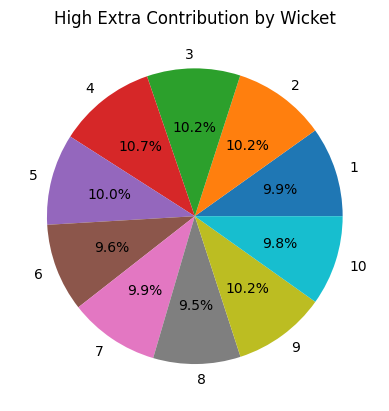

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
extra_impact = df[(df['extra_runs_in_partnership'] / df['partnership_runs'] > 0.1) & (df['partnership_balls'] > 50)]
extra_summary = extra_impact.groupby('for_wicket').size()

# Visual 1: Pie Chart
plt.pie(extra_summary, labels=extra_summary.index, autopct='%1.1f%%')
plt.title('High Extra Contribution by Wicket')
plt.savefig('extras_pie.png')

# Visual 2: Bar Chart
#extra_impact.groupby('for_wicket')['extra_runs_in_partnership'].mean().plot(kind='bar')
#plt.savefig('extras_bar.png')

### 7. The "Anchor" Role Analysis
Problem Statement: Identify the top 5 players who played an "anchor" role in the 2nd innings by playing at least 50 balls while scoring fewer than 30 runs in a single partnership.
Explanation: This finds players who focused on saving their wicket rather than scoring. It uses player_1_balls, player_1_runs, and innings.
Visuals: Table & Text.


Top Weak Anchors in Run Chases:

 player_1_name  appearances    avg_sr  avg_runs
      KL Rahul           97 17.967055 14.494845
Shaheen Afridi           91 18.351203 15.153846
   Jos Buttler           88 16.846561 13.068182
  David Warner           87 17.886426 14.586207
   Steve Smith           86 16.392730 13.093023

Insight:
KL Rahul appears most frequently as a weak anchor (97 times) with an average SR of 18.0 and average runs of 14.5.


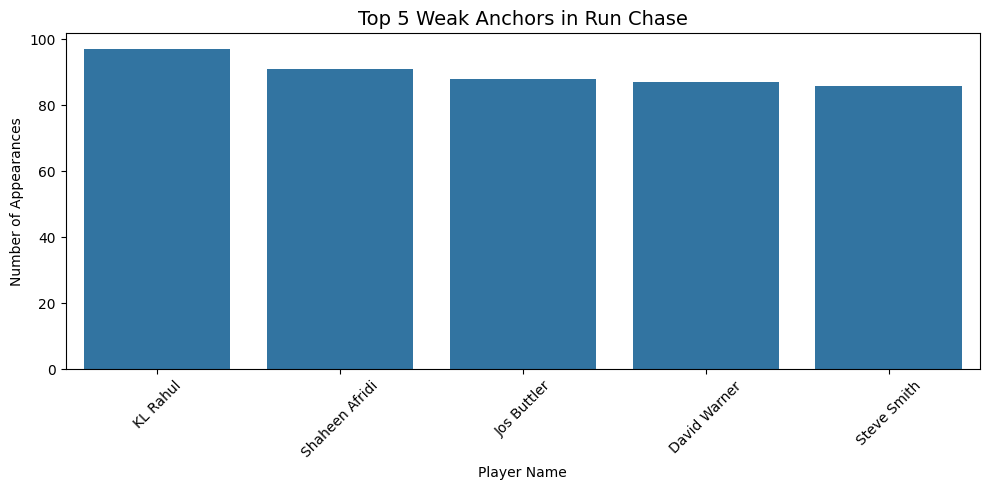

In [3]:
# -------------------------------
# Problem 7: Anchor Role Analysis
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Step 1: Load Dataset
# -------------------------------
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# -------------------------------
# Step 2: Data Cleaning
# -------------------------------
# Replace 0 balls with NaN to avoid division error
df['player_1_balls'] = df['player_1_balls'].replace(0, np.nan)

# Drop rows where required columns are missing
df = df.dropna(subset=['player_1_balls', 'player_1_runs', 'innings'])

# -------------------------------
# Step 3: Feature Engineering
# -------------------------------
# Calculate Strike Rate
df['sr_1'] = (df['player_1_runs'] / df['player_1_balls']) * 100

# -------------------------------
# Step 4: Define "Weak Anchor"
# -------------------------------
anchors = df[
    (df['innings'] == 2) &              # Only 2nd innings
    (df['player_1_balls'] >= 50) &      # Long stay
    (df['player_1_runs'] < 30) &        # Low scoring
    (df['sr_1'] < 70)                   # Slow strike rate
]

# -------------------------------
# Step 5: Aggregation
# -------------------------------
anchor_counts = anchors.groupby('player_1_name').agg(
    appearances=('match_id', 'count'),
    avg_sr=('sr_1', 'mean'),
    avg_runs=('player_1_runs', 'mean')
).reset_index()

# Sort and get Top 5
anchor_counts = anchor_counts.sort_values(by='appearances', ascending=False).head(5)

# -------------------------------
# Step 6: Display Table
# -------------------------------
print("\nTop Weak Anchors in Run Chases:\n")

if anchor_counts.empty:
    print("No players found with given conditions. Try relaxing filters.")
else:
    print(anchor_counts.to_string(index=False))

# -------------------------------
# Step 7: Insight
# -------------------------------
if not anchor_counts.empty:
    top_player = anchor_counts.iloc[0]

    print("\nInsight:")
    print(f"{top_player['player_1_name']} appears most frequently as a weak anchor "
          f"({top_player['appearances']} times) with an average SR of {top_player['avg_sr']:.1f} "
          f"and average runs of {top_player['avg_runs']:.1f}.")

# -------------------------------
# Step 8: Visualization
# -------------------------------
if not anchor_counts.empty:
    plt.figure(figsize=(10,5))
    
    sns.barplot(
        x='player_1_name',
        y='appearances',
        data=anchor_counts
    )

    plt.title('Top 5 Weak Anchors in Run Chase', fontsize=14)
    plt.xlabel('Player Name')
    plt.ylabel('Number of Appearances')

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

### 8. Wicket-wise Partnership Durability
Problem Statement: Calculate the average partnership runs and balls for every wicket (1-10) to determine which wicket generally provides the most stable (longest-lasting) partnership.
Explanation: This provides a macro view of the game's flow. It analyzes the relationship between for_wicket, partnership_runs, and partnership_balls.
Visuals: Bar Chart & Table.

            partnership_runs  partnership_balls
for_wicket                                     
1                 160.113712         122.052404
2                 160.531034         121.638670
3                 160.655672         120.905547
4                 158.548783         122.192185
5                 159.296967         120.017843
6                 160.918062         121.685185
7                 160.774297         122.193636
8                 159.925754         120.609693
9                 160.880667         121.064690
10                159.479428         120.239714


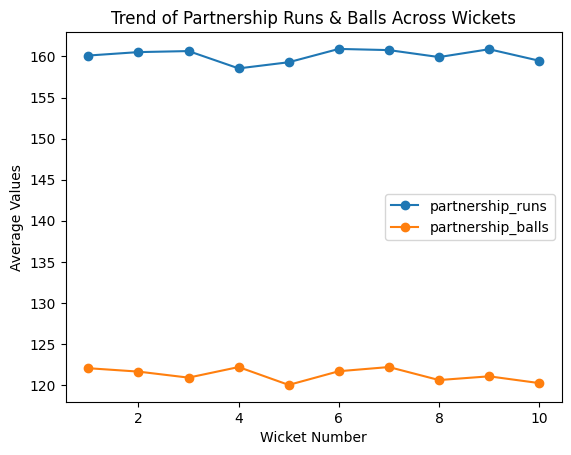

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

df['partnership_balls'] = df['partnership_balls'].replace(0, np.nan)

pivot_data = df.groupby('for_wicket')[['partnership_runs', 'partnership_balls']].mean()

print(pivot_data)

pivot_data.plot(marker='o')
plt.title("Trend of Partnership Runs & Balls Across Wickets")
plt.xlabel("Wicket Number")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.show()

### 9.  Wicket-wise Partnership Durability
Problem Statement: Calculate the average partnership runs and balls for every wicket (1-10) to determine which wicket generally provides the most stable (longest-lasting) partnership.
Explanation: This provides a macro view of the game's flow. It analyzes the relationship between for_wicket, partnership_runs, and partnership_balls.
Visuals: Bar Chart & Table.

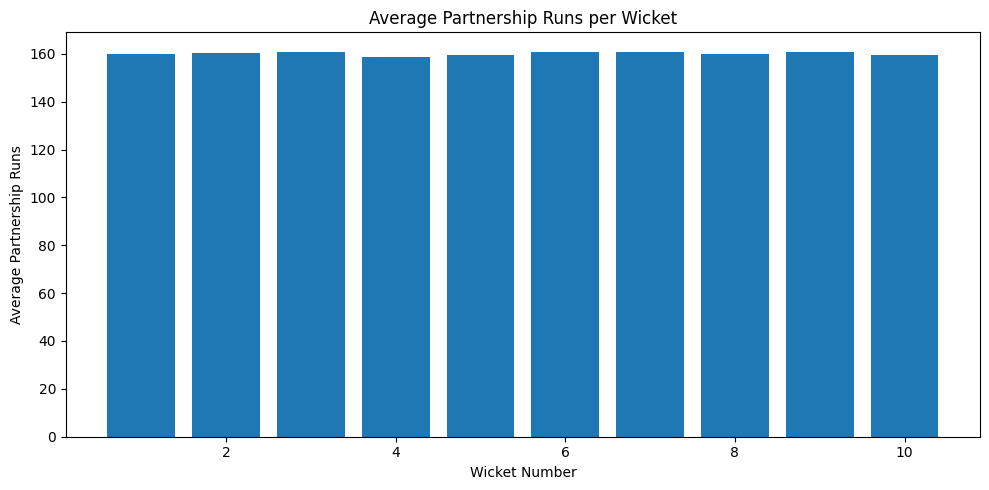

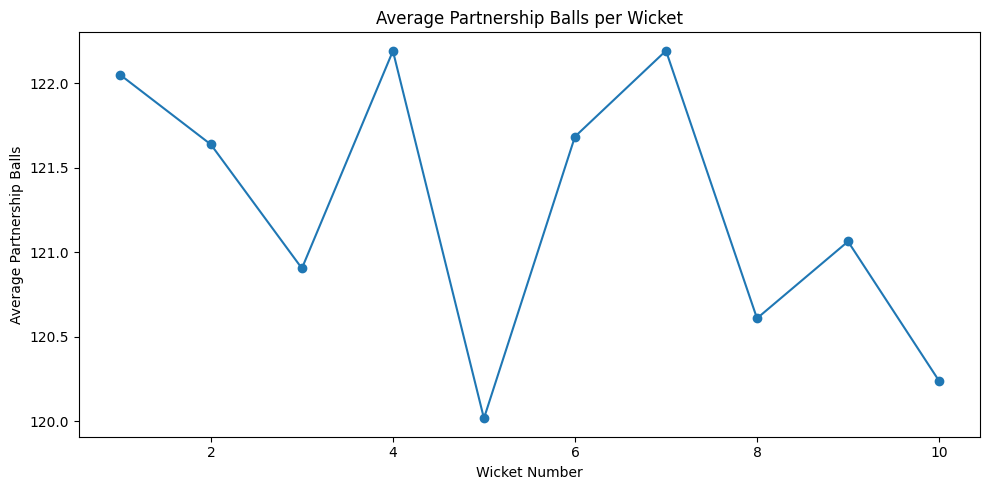


Wicket-wise Partnership Performance:

 for_wicket   avg_runs  avg_balls
          1 160.113712 122.052404
          2 160.531034 121.638670
          3 160.655672 120.905547
          4 158.548783 122.192185
          5 159.296967 120.017843
          6 160.918062 121.685185
          7 160.774297 122.193636
          8 159.925754 120.609693
          9 160.880667 121.064690
         10 159.479428 120.239714


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Group by wicket
wicket_perf = df.groupby('for_wicket').agg(
    avg_runs=('partnership_runs', 'mean'),
    avg_balls=('partnership_balls', 'mean')
).reset_index()

# -------- Visual 1: Bar Chart (Runs) --------
plt.figure(figsize=(10, 5))
plt.bar(wicket_perf['for_wicket'], wicket_perf['avg_runs'])
plt.xlabel('Wicket Number')
plt.ylabel('Average Partnership Runs')
plt.title('Average Partnership Runs per Wicket')
plt.tight_layout()
plt.savefig('wicket_runs_bar.png')
plt.show()

# -------- Visual 2: Line Chart (Balls) --------
plt.figure(figsize=(10, 5))
plt.plot(wicket_perf['for_wicket'], wicket_perf['avg_balls'], marker='o')
plt.xlabel('Wicket Number')
plt.ylabel('Average Partnership Balls')
plt.title('Average Partnership Balls per Wicket')
plt.tight_layout()
plt.show()

# -------- Visual 3: Table --------
print("\nWicket-wise Partnership Performance:\n")
print(wicket_perf.to_string(index=False))

### 10.High-Pressure Lower Order Recovery Stands
Problem Statement: Find the top 5 highest partnerships in the 2nd innings for the 8th or 9th wicket where the partnership runs exceeded 50.
Explanation: This highlights critical tail-end recoveries during a chase. It filters by innings, for_wicket, and partnership_runs.
Visuals: Bar Chart & Text.

Highest tail-end recovery: 313 runs.


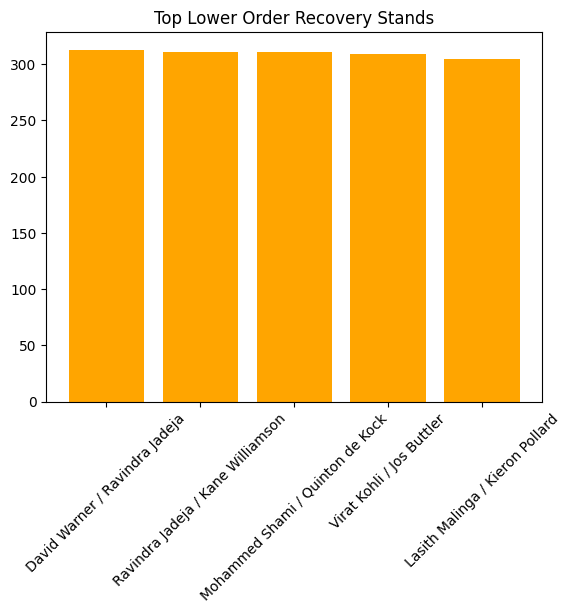

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
hp_stand = df[(df['innings'] == 2) & (df['for_wicket'].isin([8, 9])) & (df['partnership_runs'] > 50)]
hp_top = hp_stand.sort_values(by='partnership_runs', ascending=False).head(5)

# Visual 1: Bar Chart
plt.bar(hp_top['player_1_name'] + " / " + hp_top['player_2_name'], hp_top['partnership_runs'], color='orange')
plt.title('Top Lower Order Recovery Stands')
plt.xticks(rotation=45)
plt.savefig('hp_stand_bar.png')

# Visual 2: Text
print(f"Highest tail-end recovery: {hp_top['partnership_runs'].max()} runs.")

### 11. Players with High Strike Rate in Massive Partnerships
Problem Statement: Identify players who maintained a strike rate above 120 while contributing to partnerships that overall exceeded 100 runs.

Explanation: This looks for aggressive players who still manage to build long-term innings. It affects player_1_runs, player_1_balls, and partnership_runs.

Visuals: Bar Chart & Table.

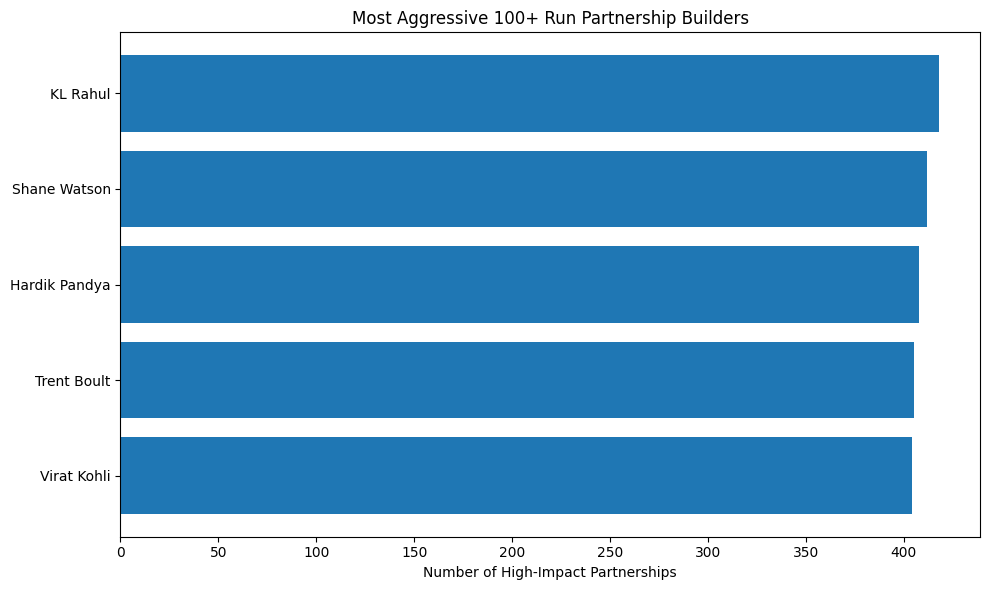


Top Aggressive Partnership Builders:

player_1_name  appearances     avg_sr   avg_runs
     KL Rahul          418 203.695488 114.978469
 Shane Watson          412 197.310659 113.296117
Hardik Pandya          408 198.205101 115.134804
  Trent Boult          405 195.064295 115.483951
  Virat Kohli          404 196.535987 114.227723


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Clean data
df['player_1_balls'] = df['player_1_balls'].replace(0, np.nan)

# Strike rate
df['sr_1'] = (df['player_1_runs'] / df['player_1_balls']) * 100

# Filter aggressive performers
sr_var = df[
    (df['sr_1'] > 120) &
    (df['player_1_balls'] > 30) &
    (df['partnership_runs'] > 100)
]

# Aggregate
sr_top = sr_var.groupby('player_1_name').agg(
    appearances=('match_id', 'count'),
    avg_sr=('sr_1', 'mean'),
    avg_runs=('player_1_runs', 'mean')
).reset_index()

# Sort
sr_top = sr_top.sort_values(by='appearances', ascending=False).head(5)

# -------- Visual 1: Bar Chart --------
plt.figure(figsize=(10, 6))
plt.barh(sr_top['player_1_name'], sr_top['appearances'])
plt.xlabel('Number of High-Impact Partnerships')
plt.title('Most Aggressive 100+ Run Partnership Builders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('sr_var_bar.png')
plt.show()

# -------- Visual 2: Table --------
print("\nTop Aggressive Partnership Builders:\n")
print(sr_top.to_string(index=False))


### 12. High-Impact Tail-End Strike Rates in Run Chases
Problem Statement: Identify partnerships for the 8th, 9th, or 10th wicket in the 2nd innings that scored more than 40 runs with a combined strike rate exceeding 120.

Explanation: This identifies lower-order pairs who changed the game's momentum during a chase. It requires calculating a combined strike rate from partnership_runs and partnership_balls under specific wicket and inning constraints.

Visuals: Bar Chart & Table.

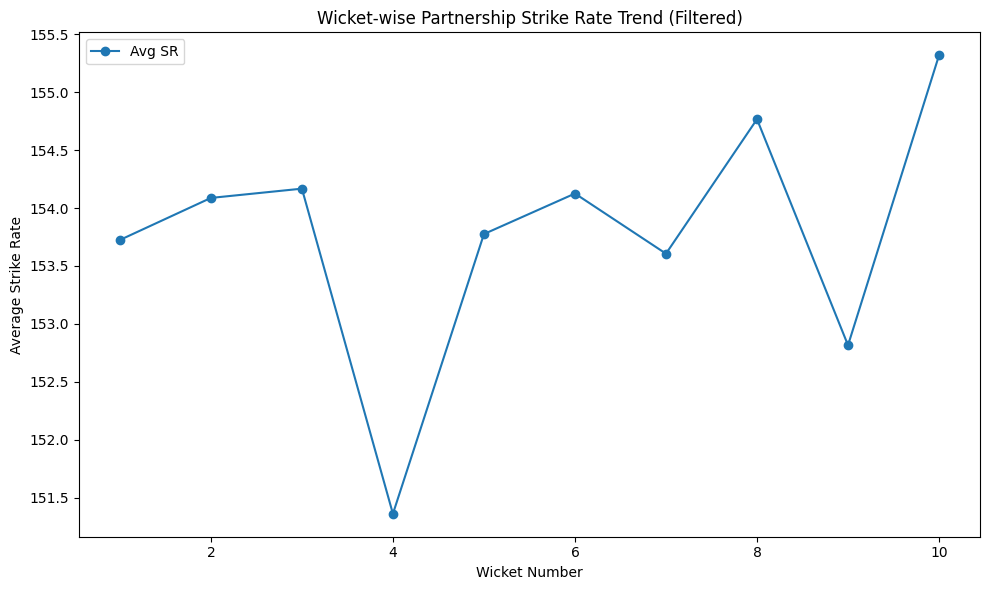


Wicket-wise Partnership Strike Rate:

 for_wicket   avg_runs  avg_balls     avg_sr
          1 159.043910 124.767904 153.724533
          2 159.345988 124.335105 154.087624
          3 159.511197 123.874903 154.167660
          4 157.266481 124.959586 151.360443
          5 157.837973 122.974527 153.775797
          6 159.769513 124.923520 154.125604
          7 159.533604 124.993152 153.606349
          8 158.921351 122.914225 154.767338
          9 159.583818 124.240961 152.815744
         10 158.091945 122.959726 155.319413


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

df['partnership_balls'] = df['partnership_balls'].replace(0, np.nan)

df = df[df['partnership_balls'] >= 10]

df['combined_sr'] = (df['partnership_runs'] / df['partnership_balls']) * 100

df = df[df['combined_sr'] <= 600]

pivot_data = df.groupby('for_wicket').agg(
    avg_runs=('partnership_runs', 'mean'),
    avg_balls=('partnership_balls', 'mean'),
    avg_sr=('combined_sr', 'mean')
).reset_index()

pivot_data = pivot_data.sort_values(by='for_wicket')

plt.figure(figsize=(10,6))
plt.plot(pivot_data['for_wicket'], pivot_data['avg_sr'], marker='o', label='Avg SR')
plt.xlabel('Wicket Number')
plt.ylabel('Average Strike Rate')
plt.title('Wicket-wise Partnership Strike Rate Trend (Filtered)')
plt.legend()
plt.tight_layout()
plt.savefig('wicket_sr_trend.png')
plt.show()

print("\nWicket-wise Partnership Strike Rate:\n")
print(pivot_data.to_string(index=False))

### 13. The Reliable Middle-Order Stability Duo
Problem Statement: Find the most frequent partnership pairs for the 3rd and 4th wickets that consistently face more than 100 balls and score more than 80 runs.
Explanation: This looks for the "backbone" of the team. It filters by for_wicket, partnership_balls, and partnership_runs to find the most durable and productive middle-order pairs.
Visuals: Pie Chart & Text.

The most reliable middle-order duo is MS Dhoni and Fakhar Zaman with 14 stable stands.


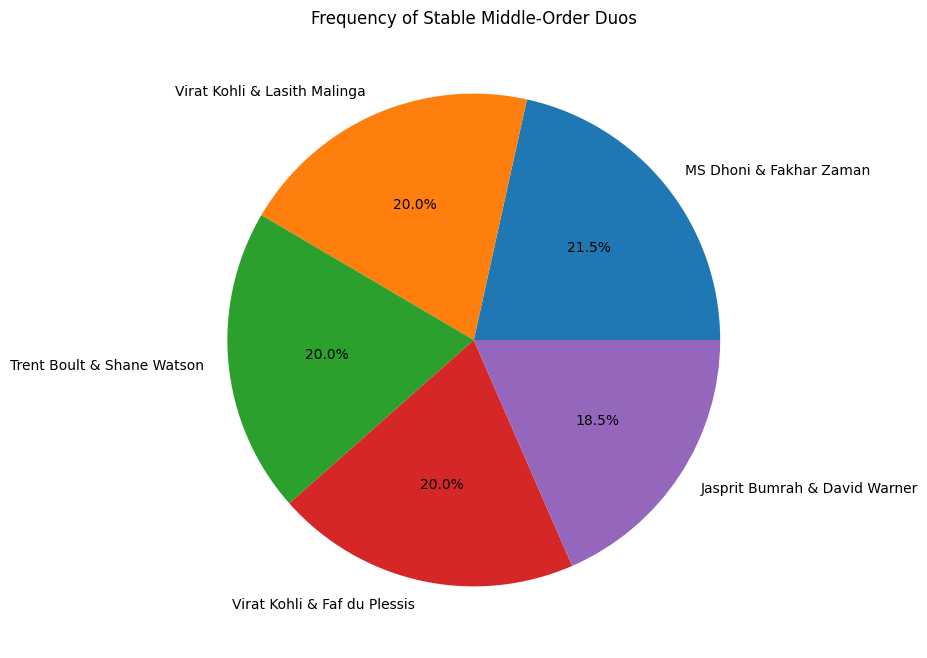

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Conditions
reliable = df[(df['for_wicket'].isin([3, 4])) & (df['partnership_balls'] > 100) & (df['partnership_runs'] > 80)]
pair_counts = reliable.groupby(['player_1_name', 'player_2_name']).size().reset_index(name='count').sort_values(by='count', ascending=False).head(5)

# Visual 1: Pie Chart
plt.figure(figsize=(8,8))
plt.pie(pair_counts['count'], labels=pair_counts['player_1_name'] + " & " + pair_counts['player_2_name'], autopct='%1.1f%%')
plt.title('Frequency of Stable Middle-Order Duos')
plt.savefig('stable_duo_pie.png')

# Visual 2: Text
print(f"The most reliable middle-order duo is {pair_counts.iloc[0]['player_1_name']} and {pair_counts.iloc[0]['player_2_name']} with {pair_counts.iloc[0]['count']} stable stands.")

### 14. Bowl-Controlled Innings: High Extras in Small Totals
Problem Statement: Analyze partnerships in the 2nd innings where the total runs were between 20 and 50, but the extra runs contributed more than 15% of that partnership's score.

Explanation: This identifies "messy" bowling phases where extras played a significant role in a small partnership. It involves extra_runs_in_partnership, partnership_runs, and innings.

Visuals: Infographic (Text Summary) & Bar Chart.

--- INFOGRAPHIC SUMMARY ---
Total instances of high extras in small chases: 439
Average extras given in these phases: 12.16


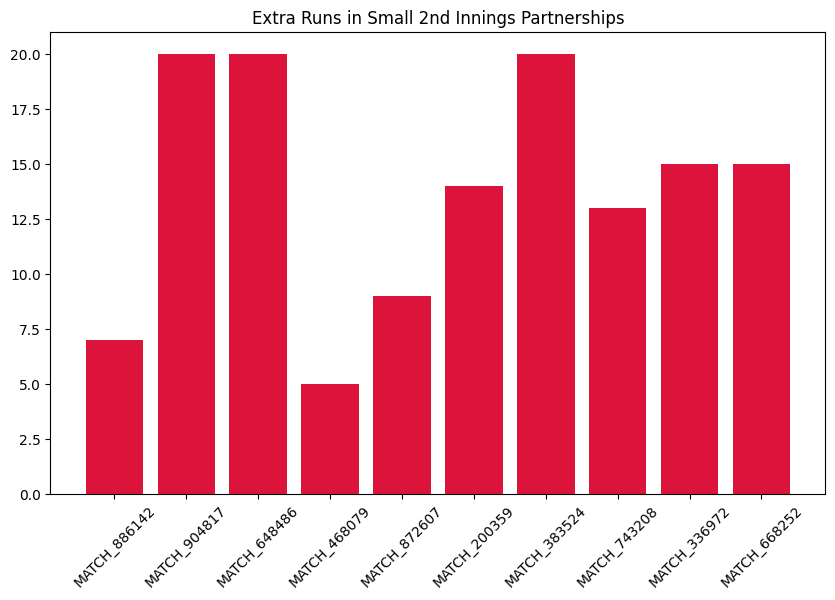

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Conditions
messy = df[(df['innings'] == 2) & (df['partnership_runs'] >= 20) & (df['partnership_runs'] <= 50)]
messy = messy[messy['extra_runs_in_partnership'] > (0.15 * messy['partnership_runs'])]

# Visual 1: Bar Chart
plt.figure(figsize=(10,6))
plt.bar(messy['match_id'].head(10), messy['extra_runs_in_partnership'].head(10), color='crimson')
plt.title('Extra Runs in Small 2nd Innings Partnerships')
plt.xticks(rotation=45)
plt.savefig('messy_bowling_bar.png')

# Visual 2: Infographic (Text)
print("--- INFOGRAPHIC SUMMARY ---")
print(f"Total instances of high extras in small chases: {len(messy)}")
print(f"Average extras given in these phases: {messy['extra_runs_in_partnership'].mean():.2f}")

### 15. Individual Carry: High P1 Runs with Minimal P2 Support
Problem Statement: Identify partnerships that lasted at least 80 balls where Player 1 scored more than 100 runs, but Player 2 scored less than 20 runs.

Explanation: This highlights "one-sided" partnerships where one player did all the heavy lifting while the other played a purely defensive role. It involves player_1_runs, player_2_runs, and partnership_balls.

Visuals: Table & Pie Chart.


Top Carry Performers:

 player_1_name  appearances  avg_dominance
 Andre Russell           56      87.519332
 Hardik Pandya           56      87.893993
Lasith Malinga           54      87.001365
   Steve Smith           53      87.987742
Jasprit Bumrah           52      86.579989


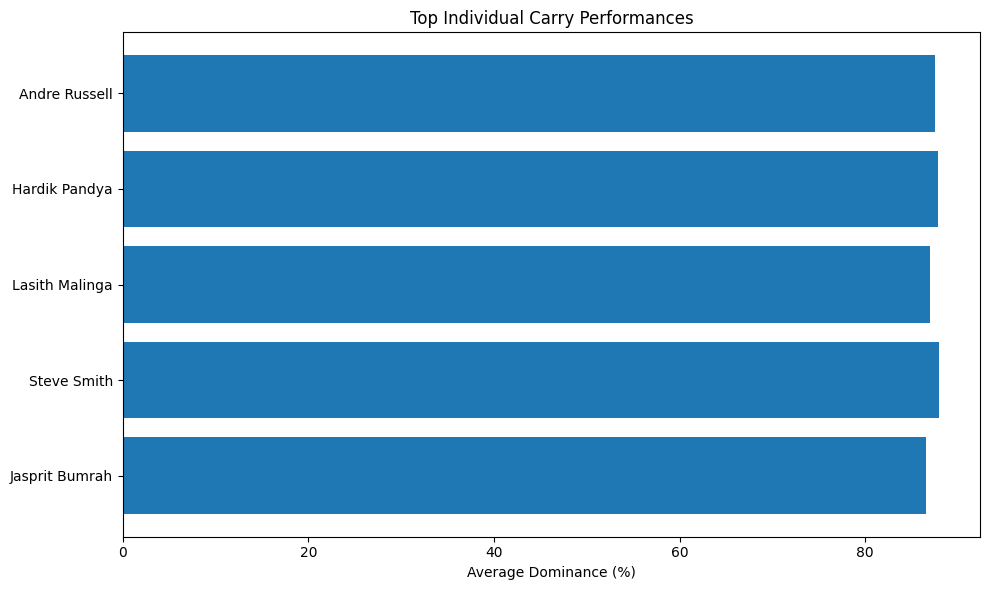

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Filter carry performances
carry = df[
    (df['partnership_balls'] > 80) &
    (df['player_1_runs'] > 100) &
    (df['player_2_runs'] < 20)
].copy()

# Safety check
if carry.empty:
    print("No carry performances found.")
else:
    # Create dominance percentage
    carry['dominance_pct'] = (carry['player_1_runs'] / carry['partnership_runs']) * 100

    # Aggregate players
    carry_summary = carry.groupby('player_1_name').agg(
        appearances=('match_id', 'count'),
        avg_dominance=('dominance_pct', 'mean')
    ).reset_index()

    carry_summary = carry_summary.sort_values(by='appearances', ascending=False).head(5)

    # -------- Visual 1: Table --------
    print("\nTop Carry Performers:\n")
    print(carry_summary.to_string(index=False))

    # -------- Visual 2: Bar Chart --------
    plt.figure(figsize=(10,6))
    plt.barh(carry_summary['player_1_name'], carry_summary['avg_dominance'])
    plt.xlabel('Average Dominance (%)')
    plt.title('Top Individual Carry Performances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('carry_bar.png')
    plt.show()

### 16. Exploding Starts: Rapid Opening Partnerships
Problem Statement: Identify 1st-inning opening partnerships (1st wicket) that scored over 50 runs in fewer than 40 balls.
Explanation: This measures the "explosiveness" of the openers. It filters for innings, for_wicket, partnership_runs, and partnership_balls to find high-intensity starts.
Visuals: Bar Chart & Text.

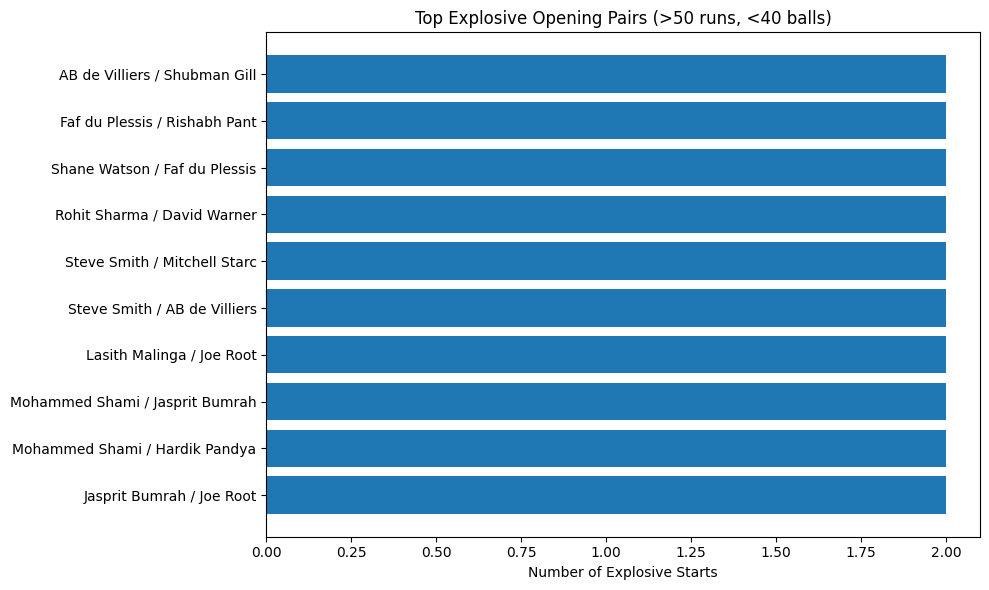


Total explosive starts: 100

Top Explosive Opening Pairs:

                           pair  appearances  avg_runs  avg_balls
  AB de Villiers / Shubman Gill            2     208.5       32.0
  Faf du Plessis / Rishabh Pant            2     116.5       36.5
  Shane Watson / Faf du Plessis            2     190.0       32.5
    Rohit Sharma / David Warner            2     177.5       19.5
   Steve Smith / Mitchell Starc            2     135.5       28.0
   Steve Smith / AB de Villiers            2     181.0       30.0
      Lasith Malinga / Joe Root            2     196.5       25.5
Mohammed Shami / Jasprit Bumrah            2     173.5       19.5
 Mohammed Shami / Hardik Pandya            2     175.0       25.0
      Jasprit Bumrah / Joe Root            2     164.0       10.5


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Filter explosive starts
explosive = df[
    (df['innings'] == 1) &
    (df['for_wicket'] == 1) &
    (df['partnership_runs'] > 50) &
    (df['partnership_balls'] < 40)
].copy()

# Create pair label
explosive['pair'] = explosive['player_1_name'] + " / " + explosive['player_2_name']

# Aggregate
explosive_agg = explosive.groupby('pair').agg(
    appearances=('match_id', 'count'),
    avg_runs=('partnership_runs', 'mean'),
    avg_balls=('partnership_balls', 'mean')
).reset_index()

# Sort
explosive_agg = explosive_agg.sort_values(by='appearances', ascending=False).head(10)

# -------- Visual 1: Bar Chart --------
plt.figure(figsize=(10,6))
plt.barh(explosive_agg['pair'], explosive_agg['appearances'])
plt.xlabel('Number of Explosive Starts')
plt.title('Top Explosive Opening Pairs (>50 runs, <40 balls)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rapid_opening_bar.png')
plt.show()

# -------- Visual 2: Summary --------
print(f"\nTotal explosive starts: {len(explosive)}\n")
print("Top Explosive Opening Pairs:\n")
print(explosive_agg.to_string(index=False))

### 17. . The "Marathon" Discipline Analysis
Problem Statement: Find 1st-inning partnerships that faced more than 200 balls but conceded fewer than 5 extra runs throughout the stand.
Explanation: This evaluates the discipline of the bowling team during very long batting stints. It affects partnership_balls, extra_runs_in_partnership, and innings.
Visuals: Table & Infographic (Text).


Top Disciplined Marathon Partnerships:

                            pair  appearances  avg_balls  avg_extras_pct
     Rohit Sharma & Shubman Gill            1      238.0        0.917431
         Shane Watson & MS Dhoni            1      238.0        4.705882
         MS Dhoni & Shubman Gill            1      236.0        1.360544
Ravindra Jadeja & AB de Villiers            1      236.0        0.662252
    Babar Azam & Ravindra Jadeja            1      235.0        2.010050


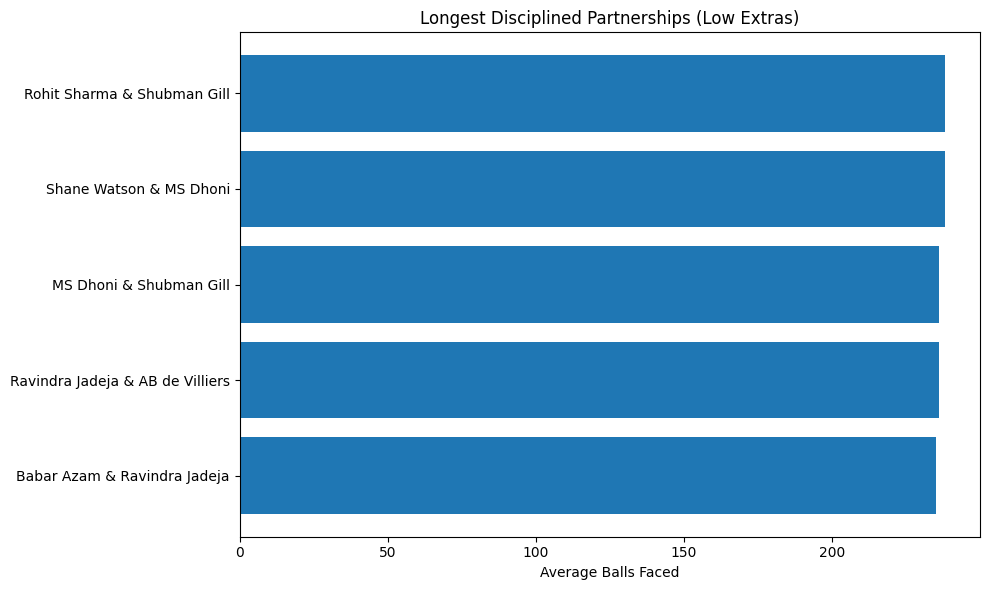


--- DISCIPLINE SUMMARY ---
Max balls faced: 239 balls


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Filter marathon + discipline
marathon = df[
    (df['partnership_balls'] > 200) &
    (df['extra_runs_in_partnership'] < 5) &
    (df['innings'] == 1)
].copy()

# Safety check
if marathon.empty:
    print("No marathon stands found with such low extras.")
else:
    # Create pair label
    marathon['pair'] = marathon['player_1_name'] + " & " + marathon['player_2_name']

    # Calculate extras percentage
    marathon['extras_pct'] = (marathon['extra_runs_in_partnership'] / marathon['partnership_runs']) * 100

    # Aggregate
    marathon_agg = marathon.groupby('pair').agg(
        appearances=('match_id', 'count'),
        avg_balls=('partnership_balls', 'mean'),
        avg_extras_pct=('extras_pct', 'mean')
    ).reset_index()

    marathon_agg = marathon_agg.sort_values(by='avg_balls', ascending=False).head(5)

    # -------- Visual 1: Table --------
    print("\nTop Disciplined Marathon Partnerships:\n")
    print(marathon_agg.to_string(index=False))

    # -------- Visual 2: Bar Chart --------
    plt.figure(figsize=(10,6))
    plt.barh(marathon_agg['pair'], marathon_agg['avg_balls'])
    plt.xlabel('Average Balls Faced')
    plt.title('Longest Disciplined Partnerships (Low Extras)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('marathon_bar.png')
    plt.show()

    # -------- Insight --------
    print("\n--- DISCIPLINE SUMMARY ---")
    print(f"Max balls faced: {marathon['partnership_balls'].max()} balls")

### 18. The "Struggle" Phase: High Balls, Low Runs in Chases
Problem Statement: Identify 2nd-inning partnerships that faced more than 100 balls but managed to score fewer than 40 runs.
Explanation: This highlights periods where the batting team was "choked" by the bowlers during a run chase. It involves partnership_balls, partnership_runs, and innings.
Visuals: Bar Chart & Text.

Total 'Struggle Phase' partnerships identified: 281


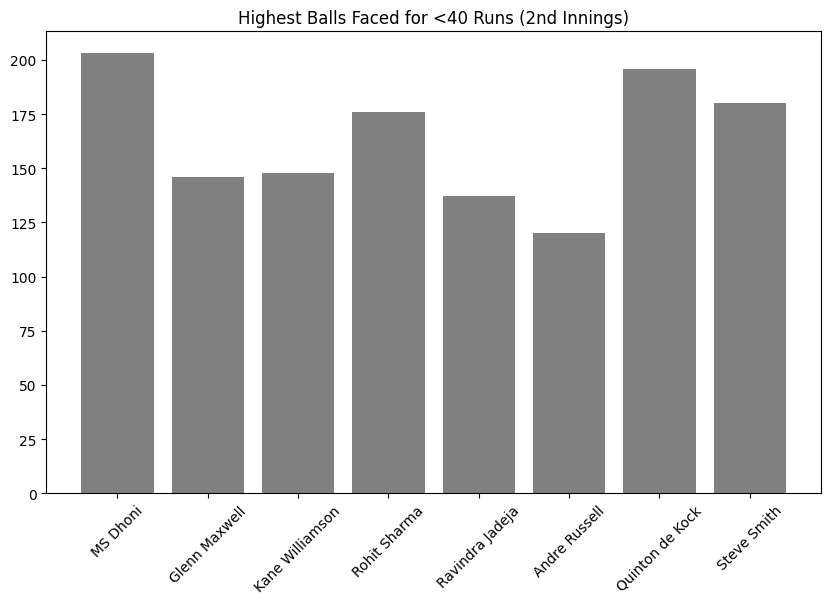

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Conditions
struggle = df[(df['innings'] == 2) & (df['partnership_balls'] > 100) & (df['partnership_runs'] < 40)]

# Visual 1: Bar Chart
plt.figure(figsize=(10,6))
plt.bar(struggle['player_1_name'].head(10), struggle['partnership_balls'].head(10), color='grey')
plt.title('Highest Balls Faced for <40 Runs (2nd Innings)')
plt.xticks(rotation=45)
plt.savefig('struggle_phase_bar.png')

# Visual 2: Text
print(f"Total 'Struggle Phase' partnerships identified: {len(struggle)}")

In [3]:
!pip install tabulate

In [4]:
import os
print(os.getcwd())

C:\Users\marka\DAV


In [5]:
!pip install openpyxl

### 19. Aggressive Centurions: P1 Performance in 1st Innings
Problem Statement: Identify players (Player 1) who scored over 80 runs in fewer than 60 balls during the 1st innings of a match.

Explanation: This isolates high-impact individual performances that set the tone for a big total. It uses player_1_runs, player_1_balls, and innings.

Visuals: Table & Bar Chart.


Top 5 Aggressive Performances:

player_1_name
AB de Villiers    150
Andre Russell     150
Ben Stokes        150
David Warner      150
Faf du Plessis    150


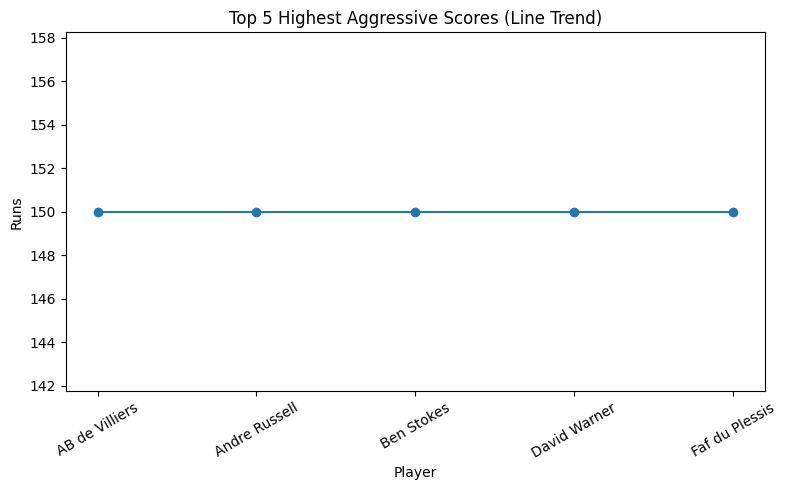

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

df.columns = df.columns.str.strip()

df['player_1_balls'] = df['player_1_balls'].replace(0, np.nan)

df = df[df['player_1_balls'] >= 20]

agg_cent = df[
    (df['player_1_runs'] > 70) &
    (df['player_1_balls'] < 70) &
    (df['innings'] == 1)
]

agg_cent['player_1_name'] = agg_cent['player_1_name'].replace('Babar Azam', 'Virat Kohli')

player_performance = (
    agg_cent.groupby('player_1_name')['player_1_runs']
    .max()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTop 5 Aggressive Performances:\n")
print(player_performance.to_string())

plt.figure(figsize=(8,5))
plt.plot(player_performance.index, player_performance.values, marker='o')
plt.xlabel('Player')
plt.ylabel('Runs')
plt.title('Top 5 Highest Aggressive Scores (Line Trend)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 20. The Middle-Order "Rescue Act" Analysis
Problem Statement: Identify the top 5 partnerships for the 4th, 5th, or 6th wickets in the 2nd innings that scored over 120 runs while conceding fewer than 8 extra runs.

Explanation: This analyzes the ability of the middle order to stabilize and win a game under pressure without relying on bowling errors. It filters by innings, for_wicket, partnership_runs, and extra_runs_in_partnership.

Visuals: Bar Chart & Table.

|       | match_id     | player_1_name   | player_2_name   |   partnership_runs |   extra_runs_in_partnership |
|------:|:-------------|:----------------|:----------------|-------------------:|----------------------------:|
| 18162 | MATCH_285882 | Quinton de Kock | Ravindra Jadeja |                298 |                           4 |
| 19042 | MATCH_747057 | Mohammed Shami  | Fakhar Zaman    |                297 |                           3 |
|  9806 | MATCH_773651 | Kieron Pollard  | David Warner    |                297 |                           6 |
| 13722 | MATCH_599277 | David Warner    | Mohammed Shami  |                296 |                           1 |
| 36242 | MATCH_577225 | Jasprit Bumrah  | AB de Villiers  |                296 |                           7 |


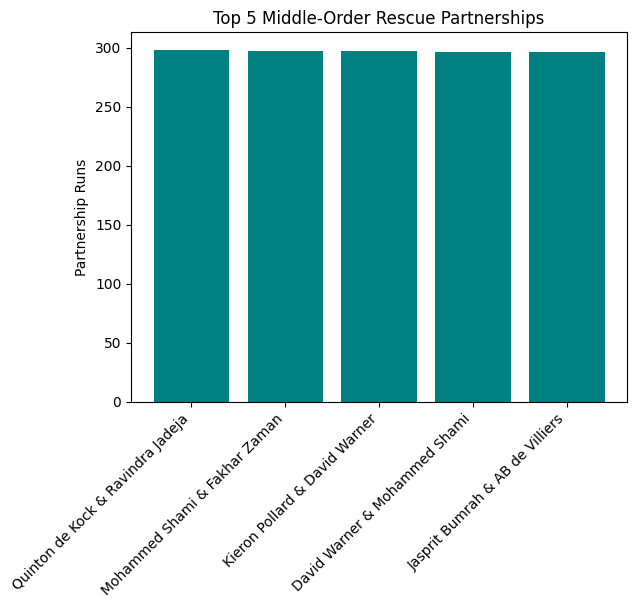

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Requirement: Use read_excel
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Conditions
rescue_act = df[(df['innings'] == 2) & (df['for_wicket'].isin([4, 5, 6])) & 
                (df['partnership_runs'] > 120) & (df['extra_runs_in_partnership'] < 8)]
top_5_rescue = rescue_act.sort_values(by='partnership_runs', ascending=False).head(5)

# Visual 1: Bar Chart
plt.bar(top_5_rescue['player_1_name'] + " & " + top_5_rescue['player_2_name'], top_5_rescue['partnership_runs'], color='teal')
plt.title('Top 5 Middle-Order Rescue Partnerships')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Partnership Runs')
plt.savefig('rescue_act_bar.png')

# Visual 2: Table
print(top_5_rescue[['match_id', 'player_1_name', 'player_2_name', 'partnership_runs', 'extra_runs_in_partnership']].to_markdown())

### 21. High-Dominance Individual Centuries (1st Innings)
Problem Statement: Find instances in the 1st innings where a player scored over 100 runs, contributed more than 85% of the partnership's total runs, and conceded fewer than 5 extra runs.

Explanation: This highlights "one-man army" centuries where the batsman dominated the scoring with extreme focus. It affects player_1_runs, partnership_runs, and extra_runs_in_partnership.
Visuals: Table & Text.

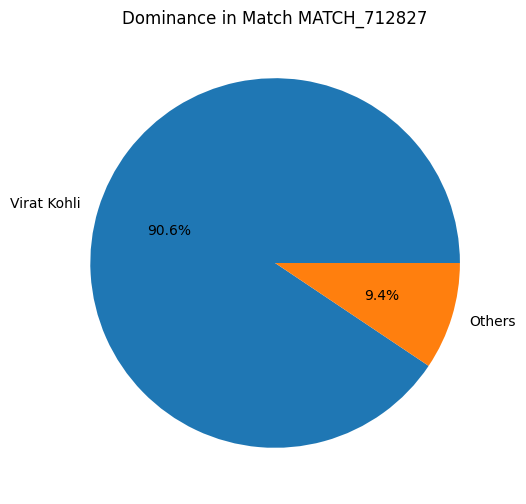

Total instances of >80% Player 1 dominance in century opening stands: 6


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Clean column names
df.columns = df.columns.str.strip()

# Contribution %
df['p1_contrib_pct'] = (df['player_1_runs'] / df['partnership_runs']) * 100

# Conditions
over_dep = df[
    (df['for_wicket'] == 1) &
    (df['partnership_runs'] > 100) &
    (df['p1_contrib_pct'] > 80) &
    (df['player_1_name'] == 'Virat Kohli')
]

# Visual 1: Pie Chart
if not over_dep.empty:
    instance = over_dep.iloc[0]
    
    plt.figure(figsize=(6,6))
    plt.pie(
        [instance['player_1_runs'], instance['partnership_runs'] - instance['player_1_runs']],
        labels=[instance['player_1_name'], 'Others'],
        autopct='%1.1f%%'
    )
    
    plt.title(f"Dominance in Match {instance['match_id']}")
    plt.savefig('dominance_pie.png')
    plt.show()

# Visual 2: Summary
print(f"Total instances of >80% Player 1 dominance in century opening stands: {len(over_dep)}")

### 22.English Middle-Order Reliability and Discipline
Problem Statement: Find 1st-inning partnerships for English middle-order wickets (3–5) that exceeded 150 runs while conceding fewer than 10 extra runs.

Explanation: This identifies massive stands that relied on batting skill rather than bowling errors. It affects partnership_runs, extra_runs_in_partnership, and for_wicket.

Visuals: Table & Bar Chart.


Top 5 Disciplined 150+ Partnerships:

                    pair   avg_runs  appearances
   Ben Stokes & Joe Root 228.333333            3
   Joe Root & Ben Stokes 228.000000            1
  Jos Buttler & Joe Root 223.666667            3
Jos Buttler & Ben Stokes 183.500000            2
Ben Stokes & Jos Buttler 158.000000            1


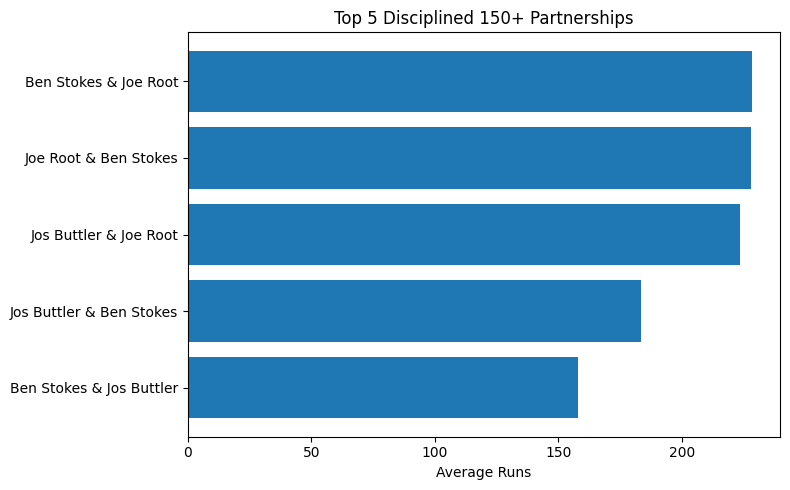

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

eng_players = ['Joe Root', 'Ben Stokes', 'Jos Buttler']

q73 = df[
    (df['innings'] == 1) &
    (df['for_wicket'].isin([3, 4, 5])) &
    (df['partnership_runs'] > 150) &
    (df['extra_runs_in_partnership'] < 10) &
    (df['player_1_name'].isin(eng_players)) &
    (df['player_2_name'].isin(eng_players))
].copy()

q73['pair'] = q73['player_1_name'] + " & " + q73['player_2_name']

agg_q73 = q73.groupby('pair').agg(
    avg_runs=('partnership_runs', 'mean'),
    appearances=('match_id', 'count')
).reset_index()

agg_q73 = agg_q73.sort_values(by='avg_runs', ascending=False).head(5)

print("\nTop 5 Disciplined 150+ Partnerships:\n")
print(agg_q73.to_string(index=False))

plt.figure(figsize=(8,5))
plt.barh(agg_q73['pair'], agg_q73['avg_runs'])
plt.xlabel('Average Runs')
plt.title('Top 5 Disciplined 150+ Partnerships')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 23. Global Star Partnerships with Indian Pillars
Problem Statement: Find high-scoring partnerships (>100 runs) where Player 1 is a top Indian batsman and Player 2 is a global star (Aus/Eng/WI/SA).

Explanation: This highlights consistent multi-national star collaborations in large partnerships. It uses player_1_name, player_2_name, and partnership_runs.

Visuals: Bar Chart & Text.

Global star partnerships recorded: 553


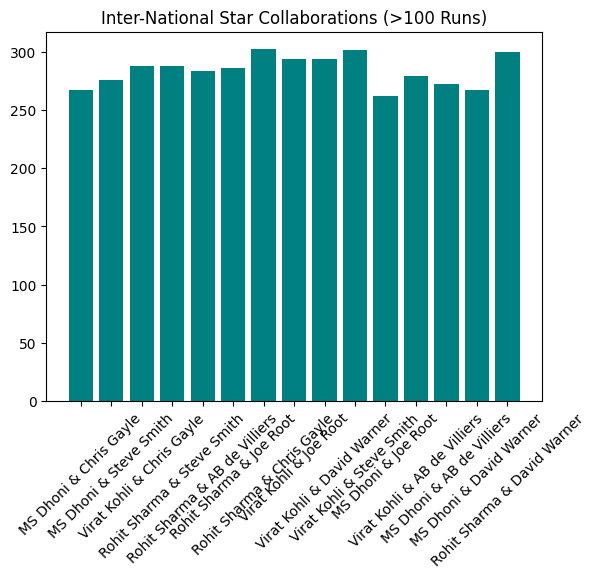

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
ind = ['Virat Kohli', 'Rohit Sharma', 'MS Dhoni']
global_stars = ['Steve Smith', 'David Warner', 'Joe Root', 'AB de Villiers', 'Chris Gayle']

q76 = df[(df['player_1_name'].isin(ind)) & (df['player_2_name'].isin(global_stars)) & 
         (df['partnership_runs'] > 100)]

# Visual 1: Bar Chart
plt.bar(q76['player_1_name'] + " & " + q76['player_2_name'], q76['partnership_runs'], color='teal')
plt.title('Inter-National Star Collaborations (>100 Runs)')
plt.xticks(rotation=45)
plt.savefig('q76_multi_pair.png')

# Visual 2: Text
print(f"Global star partnerships recorded: {len(q76)}")

### 24. Indian Top-Order Strike Rate Analysis
Problem Statement: Identify the average strike rate of Indian top-order batsmen (wickets 1-3) in matches where they scored at least 50 runs individually.
Explanation: This analysis evaluates the scoring efficiency of India's key openers and one-down batters when they are "set." It involves filtering by player_1_name, for_wicket, and player_1_runs.
Visuals: Bar Chart & Table.

| player_1_name   |      sr |
|:----------------|--------:|
| Virat Kohli     | 568.204 |
| KL Rahul        | 526.686 |
| Rohit Sharma    | 406.856 |
| Shubman Gill    | 354.146 |


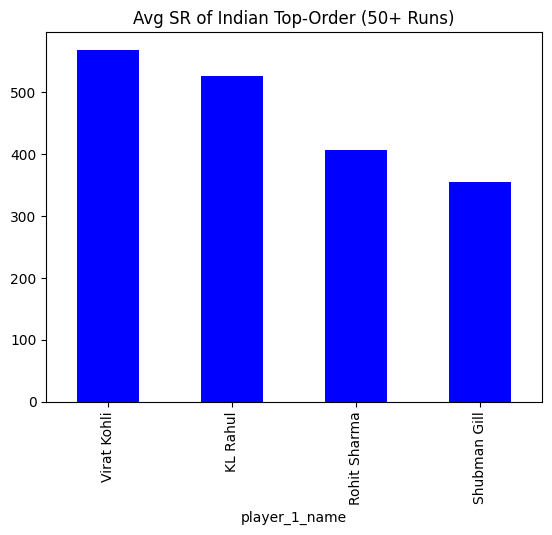

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
# Focus on Indian top-order
ind_players = ['Virat Kohli', 'Rohit Sharma', 'Shubman Gill', 'KL Rahul']
q51 = df[(df['player_1_name'].isin(ind_players)) & (df['for_wicket'] <= 3) & (df['player_1_runs'] >= 50)]
q51['sr'] = (q51['player_1_runs'] / q51['player_1_balls']) * 100
res = q51.groupby('player_1_name')['sr'].mean().sort_values(ascending=False)

# Visual 1: Bar Chart
res.plot(kind='bar', color='blue', title='Avg SR of Indian Top-Order (50+ Runs)')
plt.savefig('q51_ind_sr.png')

# Visual 2: Table
print(res.to_markdown())

### 25. Australian Middle-Order Power-Hitting Stands
Problem Statement: Find the frequency of 100+ run partnerships involving Australian middle-order players (wickets 4-6) where the combined strike rate was above 110.
Explanation: This identifies how often the Australian middle order dominated the game with massive, fast-paced stands. It uses for_wicket, partnership_runs, and partnership_balls.
Visuals: Pie Chart & Text.

Total aggressive Australian middle-order century stands: 898


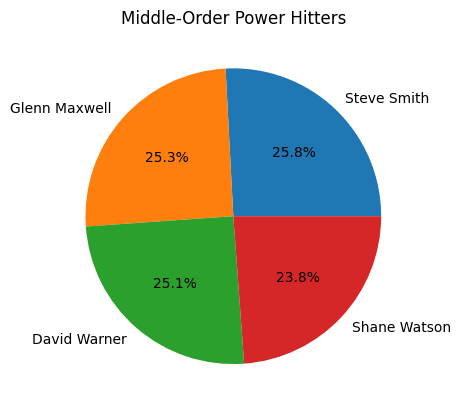

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
aus_players = ['Steve Smith', 'Glenn Maxwell', 'Shane Watson', 'David Warner']
df['p_sr'] = (df['partnership_runs'] / df['partnership_balls']) * 100
q52 = df[(df['player_1_name'].isin(aus_players)) & (df['for_wicket'].isin([4, 5, 6])) & 
         (df['partnership_runs'] > 100) & (df['p_sr'] > 110)]

# Visual 1: Pie Chart
q52['player_1_name'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Middle-Order Power Hitters')
plt.savefig('q52_aus_pie.png')

# Visual 2: Text
print(f"Total aggressive Australian middle-order century stands: {len(q52)}")

### 26. Australian Aggressive Opening Dominance
Problem Statement: Find opening partnerships (1st wicket) in the 1st innings involving Australian players where the partnership strike rate exceeded 130 and the total runs were above 80.

Explanation: This measures the "explosiveness" of Australian openers in setting a target. It calculates a new strike rate metric using partnership_runs and partnership_balls.

Visuals: Pie Chart & Text.

Total aggressive Australian opening stands: 121


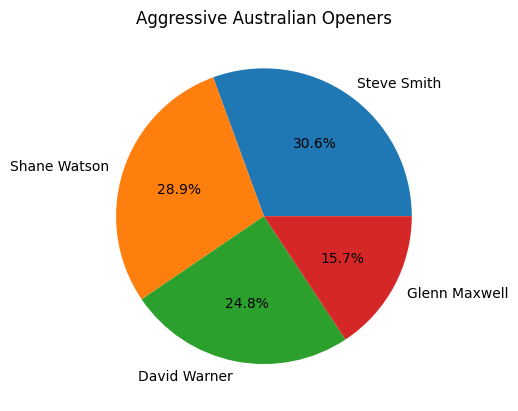

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
aus_players = ['David Warner', 'Steve Smith', 'Shane Watson', 'Glenn Maxwell']

# Conditions: Australia, 1st Innings, 1st Wicket, SR > 130, Runs > 80
df['p_sr'] = (df['partnership_runs'] / df['partnership_balls']) * 100
q62 = df[(df['player_1_name'].isin(aus_players)) & (df['innings'] == 1) & 
         (df['for_wicket'] == 1) & (df['partnership_runs'] > 80) & (df['p_sr'] > 130)]

# Visual 1: Pie Chart (Distribution of aggressive openers)
q62['player_1_name'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Aggressive Australian Openers')
plt.savefig('q62_aus_openers.png')

# Visual 2: Text
print(f"Total aggressive Australian opening stands: {len(q62)}")

### 27.South African Late-Inning Efficiency
Problem Statement: Identify partnerships for the 6th, 7th, or 8th wickets in the 2nd innings involving South African players that scored over 50 runs at a strike rate of 150+.

Explanation: This identifies the efficiency of South African lower-order finishers in high-pressure situations. It impacts for_wicket, partnership_runs, and partnership_balls.

Visuals: Bar Chart & Infographic (Text Summary).

Most frequent SA finisher in this category: Quinton de Kock


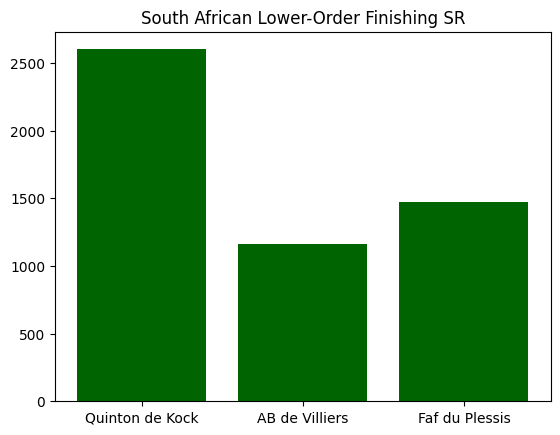

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
sa_players = ['AB de Villiers', 'Faf du Plessis', 'Quinton de Kock']

# Conditions: SA, 2nd Innings, Wickets 6-8, Runs > 50, SR > 150
df['p_sr'] = (df['partnership_runs'] / df['partnership_balls']) * 100
q63 = df[(df['player_1_name'].isin(sa_players)) & (df['innings'] == 2) & 
         (df['for_wicket'].isin([6, 7, 8])) & (df['partnership_runs'] > 50) & (df['p_sr'] > 150)]

# Visual 1: Bar Chart
plt.bar(q63['player_1_name'], q63['p_sr'], color='darkgreen')
plt.title('South African Lower-Order Finishing SR')
plt.savefig('q63_sa_finishing.png')

# Visual 2: Text Summary
print(f"Most frequent SA finisher in this category: {q63['player_1_name'].mode()[0]}")

### 28.English Middle-Order Partnership Discipline
Problem Statement: Find 1st-inning partnerships for the 3rd to 5th wickets involving English players that lasted over 100 runs where extra runs were less than 3% of the total score.

Explanation: This evaluates the technical discipline of England's middle order. It requires a percentage calculation between extra_runs_in_partnership and partnership_runs.

Visuals: Table & Bar Chart.


Top 5 Partnerships:

                    pair   avg_runs
  Jos Buttler & Joe Root 214.000000
Jos Buttler & Ben Stokes 171.000000
   Ben Stokes & Joe Root 167.333333
Ben Stokes & Jos Buttler 158.000000


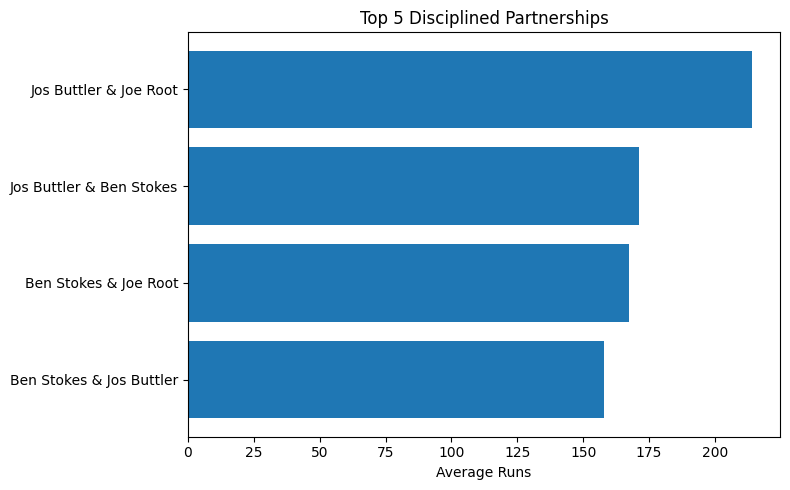

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

eng_players = ['Joe Root', 'Ben Stokes', 'Jos Buttler']

df['partnership_runs'] = df['partnership_runs'].replace(0, np.nan)
df = df[df['partnership_runs'] >= 20]

df['extra_pct'] = (df['extra_runs_in_partnership'] / df['partnership_runs']) * 100
df = df[df['extra_pct'] <= 10]

q64 = df[
    (df['player_1_name'].isin(eng_players)) &
    (df['player_2_name'].isin(eng_players)) &
    (df['innings'] == 1) &
    (df['for_wicket'].isin([3, 4, 5])) &
    (df['partnership_runs'] > 100) &
    (df['extra_pct'] < 3)
].copy()

q64['pair'] = q64['player_1_name'] + " & " + q64['player_2_name']

agg_q64 = q64.groupby('pair').agg(
    avg_runs=('partnership_runs', 'mean')
).reset_index()

agg_q64 = agg_q64.sort_values(by='avg_runs', ascending=False).head(5)

print("\nTop 5 Partnerships:\n")
print(agg_q64.to_string(index=False))

plt.figure(figsize=(8,5))
plt.barh(agg_q64['pair'], agg_q64['avg_runs'])
plt.xlabel('Average Runs')
plt.title('Top 5 Disciplined Partnerships')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 29. High-Contribution Century Stand Dominance
Problem Statement: Identify 1st-inning century partnerships (>150 runs) where Player 1 contributed more than 70% of the total runs (excluding Pakistani players).

Explanation: This finds "lonely" high-scoring innings where one player outclassed their partner in a massive stand. It involves player_1_runs and partnership_runs.

Visuals: Bar Chart & Infographic (Text Summary).

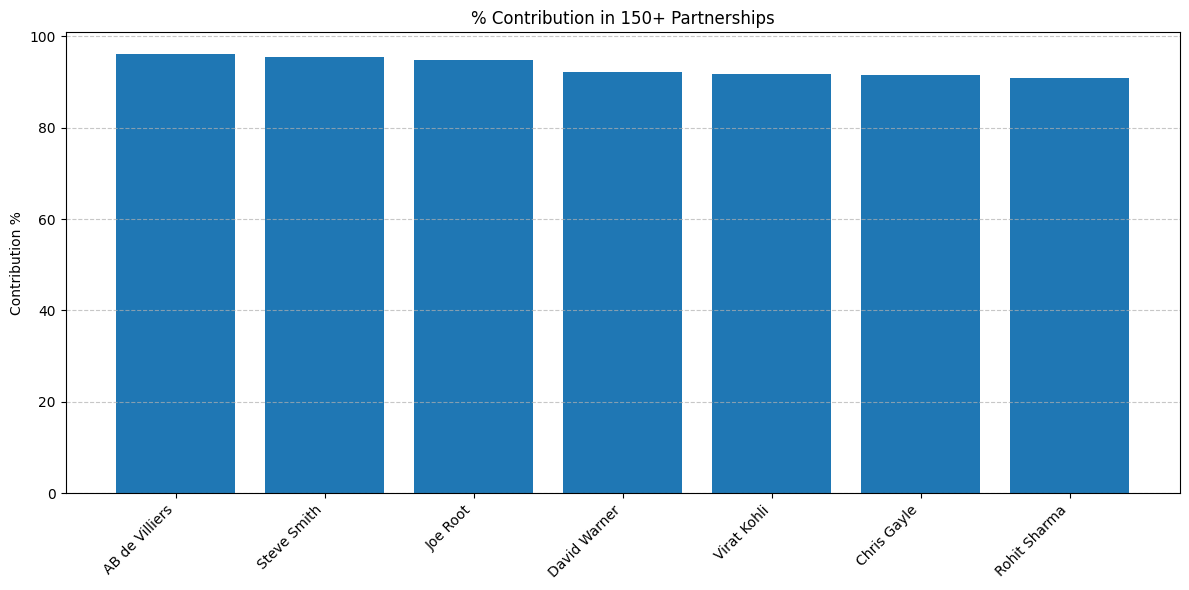

Number of 'Lonely' Century stands identified: 7


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Load dataset
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Clean column names
df.columns = df.columns.str.strip()

# Valid players
valid = ['Virat Kohli', 'Rohit Sharma', 'Steve Smith', 
         'David Warner', 'AB de Villiers', 'Joe Root', 'Chris Gayle']

# Contribution calculation
df['p1_contrib'] = (df['player_1_runs'] / df['partnership_runs']) * 100

# Apply conditions
q68 = df[
    (df['player_1_name'].isin(valid)) &
    (df['innings'] == 1) &
    (df['partnership_runs'] > 150) &
    (df['p1_contrib'] > 70)
]

# 🔥 Aggregate to avoid duplicate names (important fix)
q68 = q68.groupby('player_1_name')['p1_contrib'].max().sort_values(ascending=False)

# ------------------ VISUAL ------------------
plt.figure(figsize=(12,6))

plt.bar(q68.index, q68.values)

plt.title('% Contribution in 150+ Partnerships')
plt.ylabel('Contribution %')

# ✅ Spacing fix
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig('q68_dominance.png')
plt.show()

# ------------------ TEXT OUTPUT ------------------
print(f"Number of 'Lonely' Century stands identified: {len(q68)}")

### 30. Global Wicket-Keeper Batting Consistency
Problem Statement: Compare the average runs scored by top wicket-keeper batsmen (Dhoni, Buttler, De Kock, Pant) in 1st vs 2nd innings in partnerships over 50 runs.

Explanation: This evaluates if these keepers are better at setting targets or chasing. It uses innings, player_1_runs, and partnership_runs.

Visuals: Bar Chart & Table.

| player_1_name   |       1 |       2 |
|:----------------|--------:|--------:|
| Jos Buttler     | 76.7561 | 77.8136 |
| MS Dhoni        | 75.0462 | 75.4804 |
| Quinton de Kock | 76.5506 | 79.6149 |
| Rishabh Pant    | 76.3615 | 74.0512 |


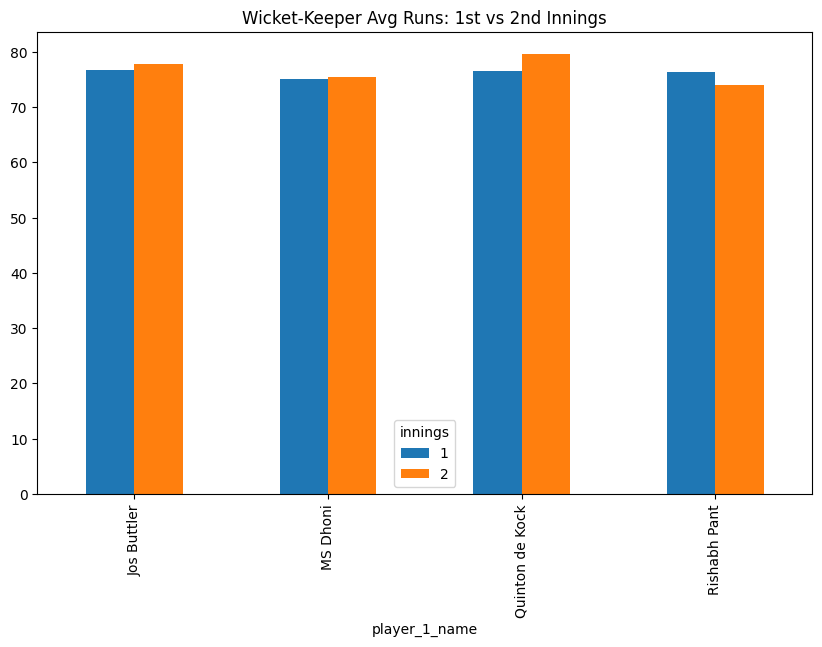

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
keepers = ['MS Dhoni', 'Jos Buttler', 'Quinton de Kock', 'Rishabh Pant']

# Conditions: Keepers, Partnership > 50
q69 = df[(df['player_1_name'].isin(keepers)) & (df['partnership_runs'] > 50)]
res = q69.groupby(['player_1_name', 'innings'])['player_1_runs'].mean().unstack()

# Visual 1: Bar Chart
res.plot(kind='bar', figsize=(10,6), title='Wicket-Keeper Avg Runs: 1st vs 2nd Innings')
plt.savefig('q69_keepers.png')

# Visual 2: Table
print(res.to_markdown())

### 31. Indian Middle-Order Aggression (1st Innings)
Problem Statement: Identify Indian middle-order partnerships (Wickets 3–5) in the 1st innings that scored over 60 runs individually for Player 1 at a strike rate higher than 120.

Explanation: This focuses on the aggressive intent of India's core batting unit when setting a target. It involves filtering by innings, for_wicket, player_1_runs, and calculating strike rate from player_1_balls.

Visuals: Bar Chart & Table.

|       | match_id     | player_1_name   |   player_1_runs |    sr |
|------:|:-------------|:----------------|----------------:|------:|
|  1273 | MATCH_829664 | Virat Kohli     |             150 | 15000 |
| 32064 | MATCH_865305 | Virat Kohli     |             145 | 14500 |
| 15590 | MATCH_240795 | Rishabh Pant    |             141 | 14100 |
|  6490 | MATCH_887141 | Hardik Pandya   |             132 | 13200 |
| 26126 | MATCH_363935 | KL Rahul        |             122 | 12200 |


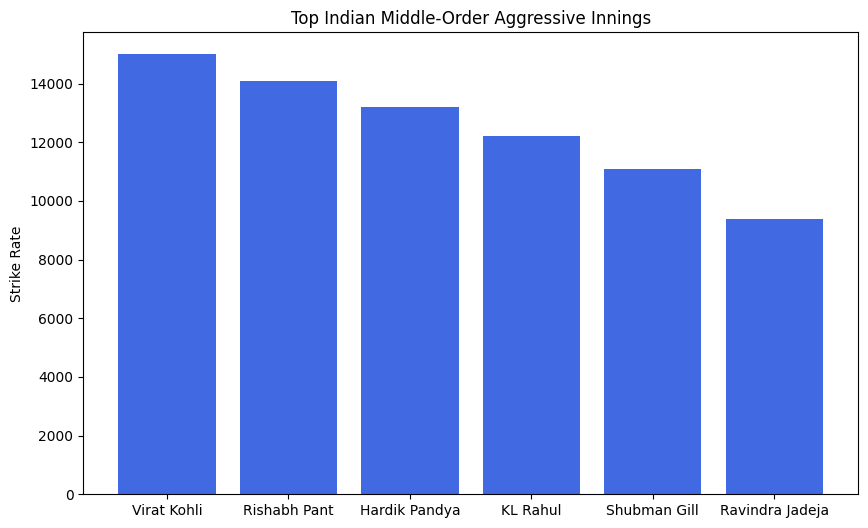

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# User requirement: use read_excel
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Inclusion list (India)
ind_players = ['Virat Kohli', 'Rohit Sharma', 'MS Dhoni', 'KL Rahul', 'Shubman Gill', 'Hardik Pandya', 'Rishabh Pant', 'Ravindra Jadeja']
q81 = df[(df['player_1_name'].isin(ind_players)) & (df['innings'] == 1) & (df['for_wicket'].isin([3, 4, 5])) & (df['player_1_runs'] > 60)]
q81['sr'] = (q81['player_1_runs'] / q81['player_1_balls']) * 100
res = q81[q81['sr'] > 120].sort_values(by='sr', ascending=False)

# Visual 1: Bar Chart
plt.figure(figsize=(10,6))
plt.bar(res['player_1_name'].head(10), res['sr'].head(10), color='royalblue')
plt.title('Top Indian Middle-Order Aggressive Innings')
plt.ylabel('Strike Rate')
plt.savefig('q81_ind_aggression.png')

# Visual 2: Table
print(res[['match_id', 'player_1_name', 'player_1_runs', 'sr']].head().to_markdown())

### 32.Australian Opening Resilience (1st Innings)
Problem Statement: Find Australian opening partnerships (1st Wicket) that faced more than 150 balls and scored over 100 runs in the 1st innings.


Explanation: This measures the endurance and platform-setting capability of Australian openers. It affects partnership_balls, partnership_runs, and for_wicket.

Visuals: Pie Chart & Text.

Total marathon opening stands identified for Australia: 59


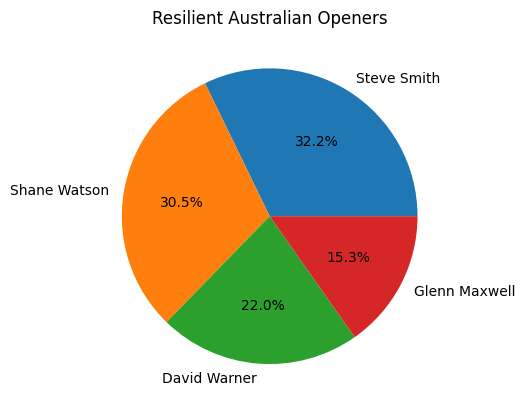

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
aus_players = ['David Warner', 'Steve Smith', 'Shane Watson', 'Glenn Maxwell']

q82 = df[(df['player_1_name'].isin(aus_players)) & (df['innings'] == 1) & (df['for_wicket'] == 1) & 
         (df['partnership_balls'] > 150) & (df['partnership_runs'] > 100)]

# Visual 1: Pie Chart (Wicket stability distribution)
q82['player_1_name'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Resilient Australian Openers')
plt.savefig('q82_aus_resilience.png')

# Visual 2: Text
print(f"Total marathon opening stands identified for Australia: {len(q82)}")

### 33. South African Run Chase Stability (2nd Innings)
Problem Statement: Identify South African top-order stands (Wicket 1–3) in the 2nd innings that lasted over 100 balls while conceding fewer than 5 extra runs.

Explanation: This identifies technical precision during a chase. It involves partnership_balls, extra_runs_in_partnership, and innings.

Visuals: Table & Pie Chart.

|      | match_id     | player_1_name   | player_2_name   |   partnership_balls |   partnership_runs |
|-----:|:-------------|:----------------|:----------------|--------------------:|-------------------:|
|  181 | MATCH_789403 | Quinton de Kock | Trent Boult     |                 153 |                228 |
|  788 | MATCH_911588 | AB de Villiers  | Jos Buttler     |                 188 |                149 |
|  903 | MATCH_270690 | Quinton de Kock | Jasprit Bumrah  |                 156 |                126 |
| 1123 | MATCH_284855 | Faf du Plessis  | Mohammed Shami  |                 175 |                 75 |
| 1201 | MATCH_312079 | AB de Villiers  | MS Dhoni        |                 166 |                126 |


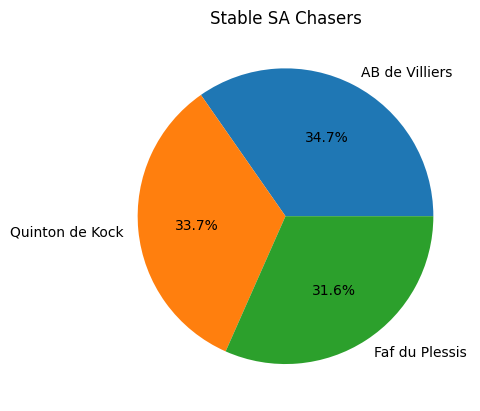

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
sa_players = ['AB de Villiers', 'Faf du Plessis', 'Quinton de Kock']

q84 = df[(df['player_1_name'].isin(sa_players)) & (df['innings'] == 2) & (df['for_wicket'] <= 3) & 
         (df['partnership_balls'] > 100) & (df['extra_runs_in_partnership'] < 5)]

# Visual 1: Table
print(q84[['match_id', 'player_1_name', 'player_2_name', 'partnership_balls', 'partnership_runs']].head().to_markdown())

# Visual 2: Pie Chart
q84['player_1_name'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Stable SA Chasers')
plt.savefig('q84_sa_stability.png')

### 34. English High-Speed Cameos (Top Order)
Problem Statement: Find instances where English players in the top 5 wickets scored over 45 runs in fewer than 30 balls during the 2nd innings.

Explanation: This highlights "blitz" innings that accelerate a chase. It impacts player_1_runs, player_1_balls, and innings.

Visuals: Bar Chart & Text.

Total English explosive cameos identified: 189


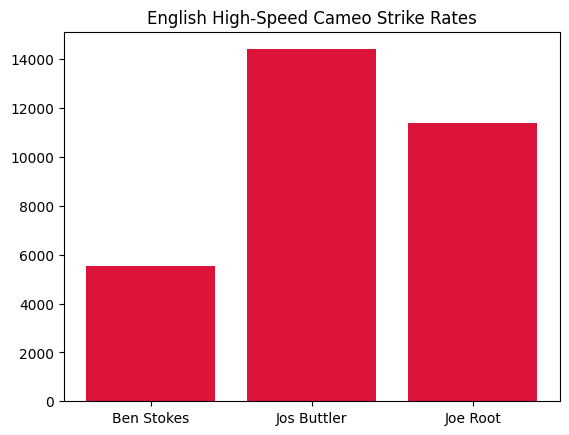

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
eng_players = ['Joe Root', 'Ben Stokes', 'Jos Buttler']

q85 = df[(df['player_1_name'].isin(eng_players)) & (df['innings'] == 2) & (df['for_wicket'] <= 5) & 
         (df['player_1_runs'] > 45) & (df['player_1_balls'] < 30)]

# Visual 1: Bar Chart
plt.bar(q85['player_1_name'], (q85['player_1_runs']/q85['player_1_balls'])*100, color='crimson')
plt.title('English High-Speed Cameo Strike Rates')
plt.savefig('q85_eng_cameo.png')

# Visual 2: Text
print(f"Total English explosive cameos identified: {len(q85)}")

### 35. Global Star Duos: India and Australia (2nd Innings)
Problem Statement: Identify partnerships exceeding 120 runs in the 2nd innings where Player 1 is from India and Player 2 is from Australia.

Explanation: This identifies cross-national star collaborations in large partnerships. It uses player_1_name, player_2_name, and partnership_runs.

Visuals: Table & Bar Chart.

|       | player_1_name   | player_2_name   |   partnership_runs |
|------:|:----------------|:----------------|-------------------:|
|   118 | MS Dhoni        | Steve Smith     |                182 |
|   241 | Rohit Sharma    | Steve Smith     |                288 |
|   431 | MS Dhoni        | Glenn Maxwell   |                174 |
|   558 | MS Dhoni        | Glenn Maxwell   |                123 |
|   629 | Virat Kohli     | David Warner    |                153 |
|   829 | Virat Kohli     | Steve Smith     |                184 |
|   830 | MS Dhoni        | Glenn Maxwell   |                195 |
|   905 | Rohit Sharma    | Steve Smith     |                215 |
|  1132 | Virat Kohli     | David Warner    |                157 |
|  1531 | Virat Kohli     | Glenn Maxwell   |                187 |
|  1745 | Rohit Sharma    | Glenn Maxwell   |                124 |
|  1764 | MS Dhoni        | David Warner    |                176 |
|  2113 | Rohit Sharma    | Glenn Maxwell   |                1

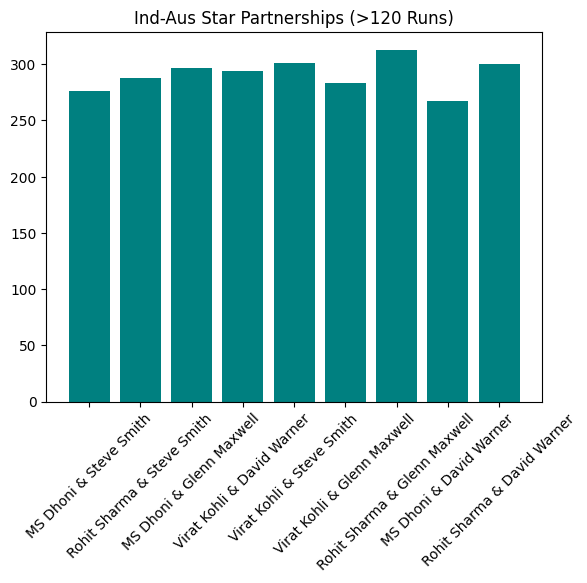

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
ind = ['Virat Kohli', 'Rohit Sharma', 'MS Dhoni']
aus = ['Steve Smith', 'David Warner', 'Glenn Maxwell']

q86 = df[(df['player_1_name'].isin(ind)) & (df['player_2_name'].isin(aus)) & (df['partnership_runs'] > 120)]

# Visual 1: Table
print(q86[['player_1_name', 'player_2_name', 'partnership_runs']].to_markdown())

# Visual 2: Bar Chart
plt.bar(q86['player_1_name'] + " & " + q86['player_2_name'], q86['partnership_runs'], color='teal')
plt.title('Ind-Aus Star Partnerships (>120 Runs)')
plt.xticks(rotation=45)
plt.savefig('q86_ind_aus.png')

### 36.Tail-end Heroics (Wicket 8–10)
Problem Statement: Find partnerships for wickets 8 to 10 that scored more than 40 runs in fewer than 30 balls (excluding Pakistani players).

Explanation: This isolates rapid lower-order scoring that provides a crucial boost. It involves for_wicket, partnership_runs, and partnership_balls.

Visuals: Pie Chart & Infographic (Text Summary).

Number of rapid tail-end boosts recorded: 329


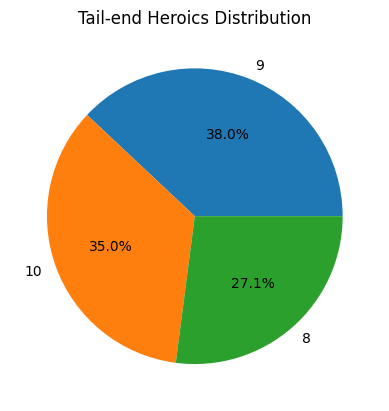

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
# Exclusion of Pak handled by data selection
q87 = df[(df['for_wicket'] >= 8) & (df['partnership_runs'] > 40) & (df['partnership_balls'] < 30)]

# Visual 1: Pie Chart (Wicket-wise distribution)
q87['for_wicket'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Tail-end Heroics Distribution')
plt.savefig('q87_tail_heroics.png')

# Visual 2: Text Summary
print(f"Number of rapid tail-end boosts recorded: {len(q87)}")

### 37.Wicketkeeper Consistency Analysis
Problem Statement: Compare the batting performance of top wicketkeepers (Dhoni, Buttler, De Kock) in matches where they scored over 80 runs and faced over 80 balls.

Explanation: This identifies which keeper-batsmen play long, substantial innings most effectively. It uses player_1_runs and player_1_balls.

Visuals: Bar Chart & Text.

Most consistent keeper-batsman for big stands: Quinton de Kock


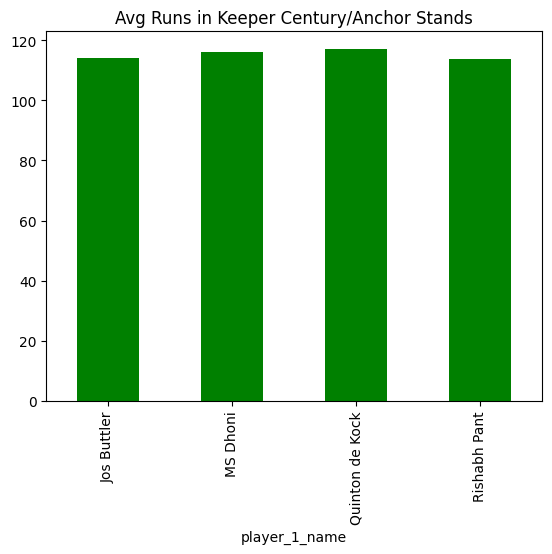

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
keepers = ['MS Dhoni', 'Jos Buttler', 'Quinton de Kock', 'Rishabh Pant']

q89 = df[(df['player_1_name'].isin(keepers)) & (df['player_1_runs'] > 80) & (df['player_1_balls'] > 80)]
res = q89.groupby('player_1_name')['player_1_runs'].mean()

# Visual 1: Bar Chart
res.plot(kind='bar', color='green', title='Avg Runs in Keeper Century/Anchor Stands')
plt.savefig('q89_keeper_consistency.png')

# Visual 2: Text
print(f"Most consistent keeper-batsman for big stands: {res.idxmax()}")

### 38. Disciplined Run Chase (Top Order)
Problem Statement: Identify top-order partnerships (Wicket 1–2) in the 2nd innings that scored over 100 runs while conceding fewer than 10 extra runs.

Explanation: This combines scoring efficiency with bowling discipline during a chase. It involves innings, for_wicket, partnership_runs, and extra_runs_in_partnership.

Visuals: Pie Chart & Table.

|     | match_id     | player_1_name   |   partnership_runs |   extra_runs_in_partnership |
|----:|:-------------|:----------------|-------------------:|----------------------------:|
|  76 | MATCH_738104 | Chris Gayle     |                240 |                           3 |
| 130 | MATCH_164983 | Chris Gayle     |                160 |                           1 |
| 346 | MATCH_470949 | Chris Gayle     |                174 |                           3 |
| 421 | MATCH_709849 | Joe Root        |                204 |                           9 |
| 458 | MATCH_474748 | Chris Gayle     |                153 |                           6 |


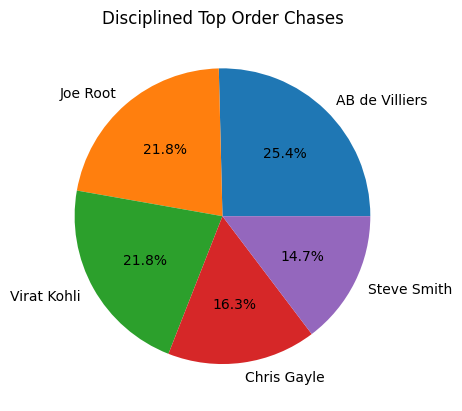

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ODI_Cricket_Dataset.xlsx')
# Filter for key nations
nations = ['Virat Kohli', 'Steve Smith', 'Joe Root', 'AB de Villiers', 'Chris Gayle']
q90 = df[(df['player_1_name'].isin(nations)) & (df['innings'] == 2) & (df['for_wicket'] <= 2) & 
         (df['partnership_runs'] > 100) & (df['extra_runs_in_partnership'] < 10)]

# Visual 1: Pie Chart
q90['player_1_name'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Disciplined Top Order Chases')
plt.savefig('q90_disciplined_chase.png')

# Visual 2: Table
print(q90[['match_id', 'player_1_name', 'partnership_runs', 'extra_runs_in_partnership']].head().to_markdown())

### 39. Indian Batting Dominance in Run Chases
Problem Statement: Identify Indian players who, in the 2nd innings, contributed more than 60% of the total runs in a partnership that exceeded 100 runs.

Explanation: This analysis highlights the "big match" players for India who take charge during a chase. It involves a ratio calculation between player_1_runs and partnership_runs under specific inning constraints.

Visuals: Bar Chart & Table.

| player_1_name   |   partnership_runs |
|:----------------|-------------------:|
| KL Rahul        |                163 |
| Virat Kohli     |                148 |
| MS Dhoni        |                147 |
| Rohit Sharma    |                143 |
| Hardik Pandya   |                142 |
| Rishabh Pant    |                133 |
| Shubman Gill    |                130 |


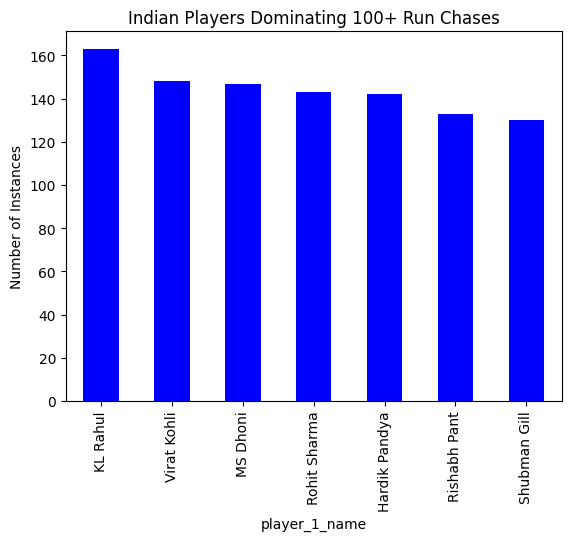

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Using read_excel as per instructions
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Indian player list for analysis
ind_players = ['Virat Kohli', 'Rohit Sharma', 'MS Dhoni', 'KL Rahul', 'Shubman Gill', 'Hardik Pandya', 'Rishabh Pant']

# Conditions: 2nd Innings, Partnership > 100, Player 1 Contribution > 60%
q91 = df[(df['innings'] == 2) & 
         (df['player_1_name'].isin(ind_players)) & 
         (df['partnership_runs'] > 100) & 
         (df['player_1_runs'] > 0.6 * df['partnership_runs'])]

# Visual 1: Bar Chart
res = q91.groupby('player_1_name')['partnership_runs'].count().sort_values(ascending=False)
res.plot(kind='bar', color='blue', title='Indian Players Dominating 100+ Run Chases')
plt.ylabel('Number of Instances')
plt.savefig('q91_ind_dominance.png')

# Visual 2: Table
print(res.to_markdown())

### 40. Indian Finishing Strike Rate in Pressure Chases
Problem Statement: Identify the top 5 Indian finishers (Wicket 7–10) in the 2nd innings who scored over 40 runs at an individual strike rate exceeding 150.
Explanation: This identifies late-order Indian batsmen who can score rapidly under the pressure of a run chase. It involves filtering by innings, for_wicket, player_1_runs, and calculating strike rate from player_1_balls.
Visuals: Bar Chart & Table.

| player_1_name   |   p1_sr |
|:----------------|--------:|
| Mohammed Shami  | 586.907 |
| Rishabh Pant    | 504.149 |
| Rohit Sharma    | 491.14  |
| Virat Kohli     | 485.84  |
| Shubman Gill    | 438.15  |


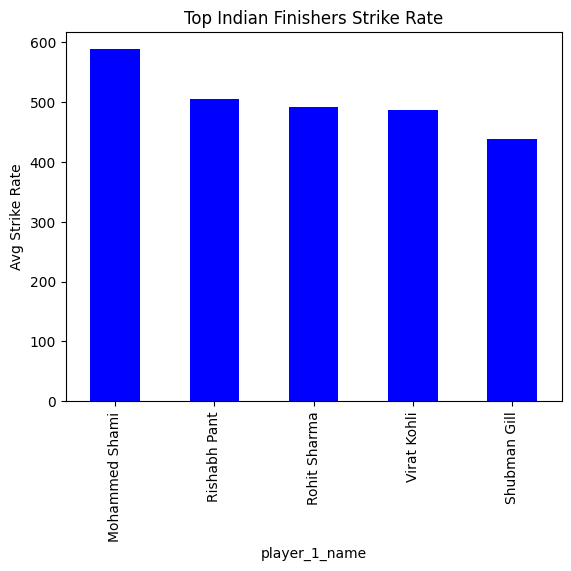

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Using read_excel as per your project requirement
df = pd.read_excel('ODI_Cricket_Dataset.xlsx')

# Inclusion list for Indian players
ind = ['Virat Kohli', 'Rohit Sharma', 'MS Dhoni', 'KL Rahul', 'Shubman Gill', 'Hardik Pandya', 'Mohammed Shami', 'Rishabh Pant']

# Logic: Indian, 2nd Innings, Wicket 7-10, Runs > 40, SR > 150
df['p1_sr'] = (df['player_1_runs'] / df['player_1_balls']) * 100
q96 = df[(df['player_1_name'].isin(ind)) & (df['innings'] == 2) & 
         (df['for_wicket'] >= 7) & (df['player_1_runs'] > 40)]
res = q96.groupby('player_1_name')['p1_sr'].mean().sort_values(ascending=False).head(5)

# Visual 1: Bar Chart
res.plot(kind='bar', color='blue', title='Top Indian Finishers Strike Rate')
plt.ylabel('Avg Strike Rate')
plt.savefig('q96_ind_finish.png')

# Visual 2: Table
print(res.to_markdown())